In [ ]:
from pathlib import Path
import sys, importlib
import os
import shutil

# ---------------------------------------------------------------------
# 1. Project Root
# ---------------------------------------------------------------------
# Für Notebooks: gehe eine Ebene hoch (von notebooks -> Projektwurzel)
if "__file__" in globals():
    root = Path(__file__).resolve().parent.parent
else:
    root = Path().resolve().parent

# Quellcode einbinden
src = root / "src"
sys.path.insert(0, str(src))

# ---------------------------------------------------------------------
# 2. Set Experiment Name BEFORE importing config
# ---------------------------------------------------------------------
os.environ["FIT_EXPERIMENT_NAME"] = "fit_notebook_final_final_123"

# ---------------------------------------------------------------------
# 3. Import config (setzt nun results/<experiment_name>/ als Root)
# ---------------------------------------------------------------------
import FIT_python.config as cfg
importlib.reload(cfg)  # recompute paths after import

# ---------------------------------------------------------------------
# 4. Experiment Directory
# ---------------------------------------------------------------------
EXP_DIR = cfg.EXPERIMENT_ROOT
EXP_DIR.mkdir(parents=True, exist_ok=True)

print("Project root directory:", root)
print("Experiment directory:", EXP_DIR)
print("RAW data directory:", cfg.RAW_DIR)

# ---------------------------------------------------------------------
# 5. Cache-Ordner löschen (alle __pycache__ unterhalb von DATA_DIR)
# ---------------------------------------------------------------------
for pycache in cfg.DATA_DIR.rglob("__pycache__"):
    shutil.rmtree(pycache)
    print(f"🗑 Cache entfernt: {pycache}")


In [ ]:
from FIT_python.data_split_and_summary.data_import_wrapper import DataImportWrapper

DataImportWrapper().clean_all()

Overview generation of Datasets in experiment

In [ ]:
from FIT_python.data_split_and_summary.dataset_summary import generate_dataset_overview

overview_df = generate_dataset_overview(cfg.RAW_DIR, EXP_DIR/'dataset_overview.parquet')
overview_df

In [ ]:
from FIT_python import config
from FIT_python.data_split_and_summary.summary_data_wrapper import run_summary
from FIT_python.data_split_and_summary.datasplit_and_summary_wraper import SplitWrapper

species = "eurasian_otter"
SplitWrapper().split_all(reuse_splits=True)

run_summary(config.SPLITS_DIR / species, species)


In [ ]:
from FIT_python.utils.paths import get_species_paths
from FIT_python.Visualisations.plots_utils import plot_feature_correlation_matrix, plot_individual_boxplots_2x1
from FIT_python import config as cfg
import pandas as pd
from FIT_python import config as cfg
from IPython.display import Image, display
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
from pathlib import Path
from matplotlib.lines import Line2D
from sklearn.feature_selection import f_classif
from sklearn.preprocessing import LabelEncoder
from IPython.display import display, Markdown
from FIT_python.data_split_and_summary.data_import_utils import get_feature_cols


otter_df = pd.read_parquet(cfg.CLEANED_DIR / "Eurasian_Otter.parquet")


species = "eurasian_otter"

# get paths managed by the config (e.g. in dataprocessing/eurasian_otter/figures)
paths = get_species_paths(species, section="dataprocessing")
fig_dir = paths["figures"]          # directory already created by get_species_paths
fig_path = plot_feature_correlation_matrix(otter_df, fig_dir)  # figure saved here

feature_cols = get_feature_cols(otter_df)
# --- Aufruf ---
plot_individual_boxplots_2x1(
    df=otter_df,
    fig_dir=fig_dir,
    filename="individual_boxplots_2x1.png",
    feature_cols=feature_cols
)


In [ ]:
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt
import itertools
from matplotlib.lines import Line2D
from FIT_python.data_split_and_summary.data_import_utils import get_feature_cols
from FIT_python.data_split_and_summary.transform_utils import convert_numeric
from FIT_python.general_pipeline_steps.dimensionality_reduction_wrapper import DimensionalityReducerTransformer
from FIT_python.utils.paths import get_species_paths


# --------------------------------
# Embedding erzeugen
# --------------------------------
# Nur gewünschte Dataorigins filtern
otter_df = otter_df[otter_df['dataorigin'].isin([
    'Vetrecova et al', 'Own Data Collection', 'Fieldprints Lower Saxony'
])]
species = "eurasian_otter"

# Features bestimmen und numerisch umwandeln
features = get_feature_cols(otter_df)
otter_df = convert_numeric(otter_df, features)
X = otter_df[features].astype(float)

# supervised UMAP mit Individual-ID und festem Seed
dr = DimensionalityReducerTransformer(
    method='umap',
    supervised=True,
    random_state=42    # Seed für Reproduzierbarkeit
)
emb = dr.fit_transform(X, otter_df['individual_id'])

# DataFrame mit Embedding und Metadaten
emb_df = pd.DataFrame(emb, index=otter_df.index, columns=dr.get_feature_names_out())
emb_df = emb_df.assign(
    individual_id=otter_df['individual_id'],
    sex_mapped=otter_df['sex'].map({'f':'Female', 'F':'Female', 0:'Female',
                                    'm':'Male', 'M':'Male', 1:'Male'}),
    dataorigin=otter_df['dataorigin']
)
# Marker-Liste für viele Individuen
markers = ['o', 's', '^', 'v', '<', '>', 'P', 'X', 'D', '*', '+', 'x', '|', '_',
           '1', '2', '3', '4', '8', 'p', 'H', 'h', 'd', '.', ',']
marker_cycle = itertools.cycle(markers)
unique_individuals = emb_df['individual_id'].unique()
marker_map = {ind: next(marker_cycle) for ind in unique_individuals}

# Kräftigere Farbpaletten für Sex mit klareren Schattierungen
sex_palette = {
    'Female': ["#800000", "#B22222", "#CD5C5C"],   # Dunkelrot → Rot → Hellrot
    'Male': ["#000080", "#0000CD", "#1E90FF"]      # Navy → Mittelblau → Hellblau
}
origin_order = ['Own Data Collection', 'Vetrecova et al', 'Fieldprints Lower Saxony']

# Farbe zuweisen basierend auf Sex und Data Origin
def assign_color(row):
    palette = sex_palette[row['sex_mapped']]
    idx = origin_order.index(row['dataorigin']) % len(palette)
    return palette[idx]

emb_df['color'] = emb_df.apply(assign_color, axis=1)

# Plot erstellen
fig, ax = plt.subplots(figsize=(12, 8))
for (sex, origin), group in emb_df.groupby(['sex_mapped', 'dataorigin']):
    for ind, subgroup in group.groupby('individual_id'):
        ax.scatter(
            subgroup['UMAP1'], subgroup['UMAP2'],
            c=subgroup['color'],
            marker=marker_map[ind],
            s=130,          # Noch größere Marker
            alpha=0.9,
            edgecolor='black',
            linewidth=0.4
        )

# Achsenbeschriftungen
ax.set_xlabel("UMAP Dimension 1")
ax.set_ylabel("UMAP Dimension 2")

# Legende nur mit Kreisen
from matplotlib.lines import Line2D
legend_elements = []
for (sex, origin), group in emb_df.groupby(['sex_mapped', 'dataorigin']):
    legend_elements.append(Line2D(
        [0], [0], marker='o', color='w', label=f"{sex}, {origin}",
        markerfacecolor=group['color'].iloc[0], markersize=10, markeredgecolor='black'
    ))

ax.legend(handles=legend_elements, title="Sex and Data Origin", fontsize=10)


species = "eurasian_otter"
fig_dir = get_species_paths(species, section="dataprocessing")["figures"]
fig_path = fig_dir / "umap_individuals_sex_origin_bigmarkers_simplelegend.png"
plt.savefig(fig_path, dpi=300)
plt.show()


C:\Users\Frede\OneDrive\Projects and Disschaptors\FIT_package\src\FIT_python\pipeline_sex\search.py:170: FutureWarning: errors='ignore' is deprecated and will raise in a future version. Use to_numeric without passing `errors` and catch exceptions explicitly instead
  df_all = pd.read_csv(all_csv).apply(pd.to_numeric, errors="ignore")
C:\Users\Frede\OneDrive\Projects and Disschaptors\FIT_package\src\FIT_python\pipeline_sex\search.py:171: FutureWarning: errors='ignore' is deprecated and will raise in a future version. Use to_numeric without passing `errors` and catch exceptions explicitly instead
  df_best = pd.read_csv(best_csv).apply(pd.to_numeric, errors="ignore")


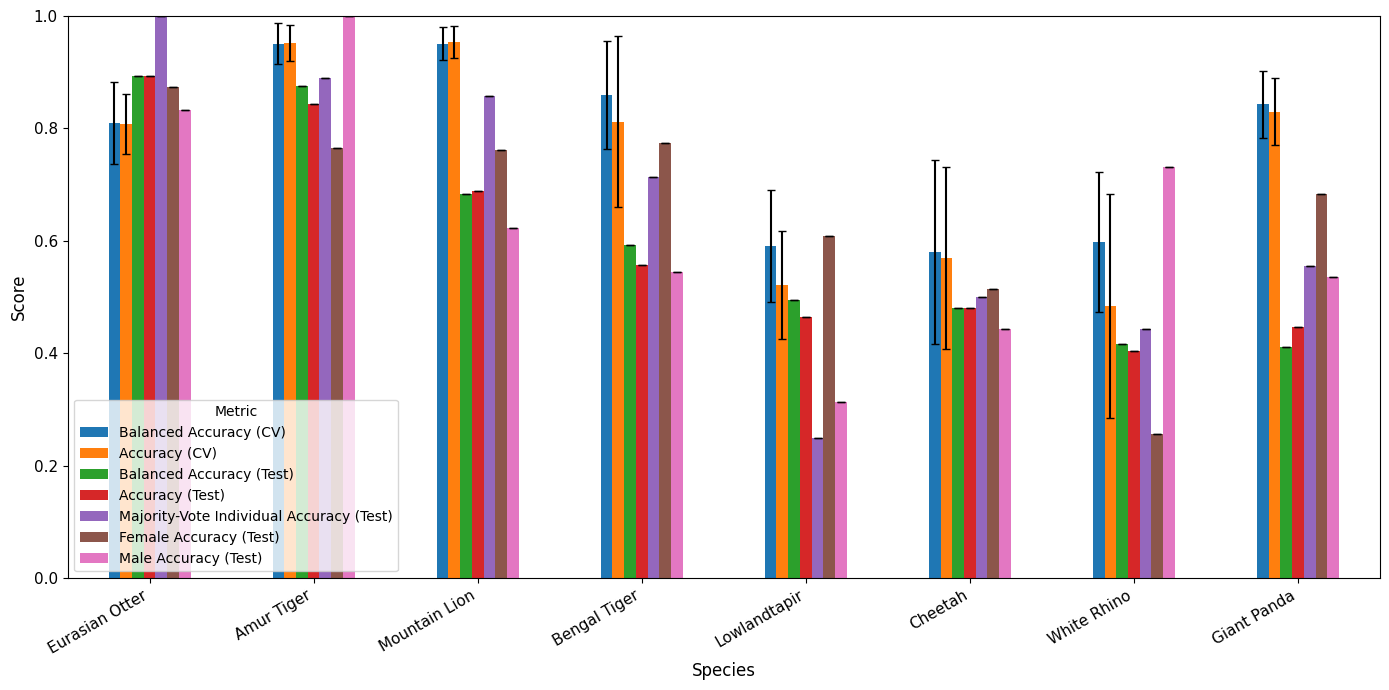

,Species,Accuracy (Test),Balanced Accuracy (Test),Majority-Vote Individual Accuracy (Test),Female Accuracy (Test),Male Accuracy (Test),Accuracy (CV),Balanced Accuracy (CV),Log Loss (CV),Accuracy (CV) SD,Balanced Accuracy (CV) SD,Log Loss (CV) SD
3,Eurasian Otter,0.893,0.893,1.000,0.874,0.833,0.808,0.809,-0.467,0.054,0.073,0.069
0,Amur Tiger,0.843,0.875,0.889,0.765,1.000,0.952,0.951,-0.172,0.032,0.036,0.086
6,Mountain Lion,0.688,0.684,0.857,0.761,0.623,0.954,0.951,-0.174,0.029,0.030,0.067
1,Bengal Tiger,0.557,0.592,0.714,0.775,0.544,0.812,0.859,-0.452,0.152,0.096,0.280
5,Lowlandtapir,0.464,0.495,0.250,0.609,0.314,0.521,0.591,-1.125,0.096,0.100,0.290
2,Cheetah,0.480,0.481,0.500,0.515,0.444,0.570,0.580,-1.149,0.162,0.163,0.613
7,White Rhino,0.405,0.417,0.444,0.256,0.731,0.484,0.598,-0.781,0.199,0.124,0.187
4,Giant Panda,0.446,0.411,0.556,0.684,0.536,0.830,0.843,-0.430,0.059,0.060,0.079


In [37]:
from FIT_python.pipeline_sex.search import (
    run_otter_search_sex,
    run_other_species_search,
    collect_best_metrics
)
import FIT_python.config as cfg

# Hyper‑parameter search (reuses previous CSVs/models if present)
run_otter_search_sex(reuse_results=True)      # Eurasian otter
#run_other_species_search()                    # all remaining species

# Summarise the best models across species
summary_df = collect_best_metrics(cfg.PATHS["sex_modelling"])
summary_df.head()

benchmark_df = summary_df

from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
# (optional) import seaborn as sns; sns.set_style("whitegrid")

# --- run searches / collect results as you already do ---
# summary_df = collect_best_metrics(cfg.PATHS["sex_modelling"])

benchmark_df = summary_df.copy()

# ---------- helpers ----------
def pick(colnames, candidates):
    """Return first existing column from candidates."""
    for c in candidates:
        if c in colnames:
            return c
    return None

cols = set(benchmark_df.columns)

# Canonical label -> possible source columns
canon_map = {
    "Species":                        ["species", "Species"],

    # Test
    "Accuracy (Test)":                ["accuracy_test", "test_accuracy"],
    "Balanced Accuracy (Test)":       ["balanced_test_acc", "test_balanced_accuracy"],
    "Majority-Vote Individual Accuracy (Test)": ["maj_test_pct", "test_majority_accuracy"],
    "Female Accuracy (Test)":         ["female_test_acc"],
    "Male Accuracy (Test)":           ["male_test_acc"],

    # CV means
    "Accuracy (CV)":                  ["mean_cv_accuracy", "mean_test_accuracy", "cv_mean_accuracy"],
    "Balanced Accuracy (CV)":         ["mean_cv_balanced_accuracy", "mean_test_balanced_accuracy", "cv_mean_balanced_accuracy"],
    "Log Loss (CV)":                  ["mean_cv_neg_log_loss", "mean_test_neg_log_loss", "cv_mean_neg_log_loss"],

    # CV std (for error bars)
    "Accuracy (CV) SD":               ["std_cv_accuracy", "std_test_accuracy", "cv_std_accuracy"],
    "Balanced Accuracy (CV) SD":      ["std_cv_balanced_accuracy", "std_test_balanced_accuracy", "cv_std_balanced_accuracy"],
    "Log Loss (CV) SD":               ["std_cv_neg_log_loss", "std_test_neg_log_loss", "cv_std_neg_log_loss"],
}

# Build a renamed dataframe with only the columns we can find
keep = {}
for label, candidates in canon_map.items():
    src = pick(cols, candidates)
    if src is not None:
        keep[label] = benchmark_df[src]

benchmark_df = pd.DataFrame(keep)

# Clean species names
if "Species" in benchmark_df.columns:
    benchmark_df["Species"] = (
        benchmark_df["Species"].astype(str)
        .str.replace("_", " ")
        .str.title()
    )

# Round and sort by Balanced Accuracy (Test) if present
benchmark_df = benchmark_df.round(3)
sort_key = "Balanced Accuracy (Test)" if "Balanced Accuracy (Test)" in benchmark_df.columns else None
if sort_key:
    benchmark_df = benchmark_df.sort_values(by=sort_key, ascending=False)

# ---------------- plotting with error bars on CV metrics ----------------
plot_cols = [c for c in [
    "Balanced Accuracy (CV)",
    "Accuracy (CV)",
    "Balanced Accuracy (Test)",
    "Accuracy (Test)",
    "Majority-Vote Individual Accuracy (Test)",
    "Female Accuracy (Test)",
    "Male Accuracy (Test)",
] if c in benchmark_df.columns]

# yerr DataFrame aligned to plot_cols (zeros where no SD available)
yerr_df = pd.DataFrame(0.0, index=benchmark_df.index, columns=plot_cols)
sd_map = {
    "Balanced Accuracy (CV)": "Balanced Accuracy (CV) SD",
    "Accuracy (CV)": "Accuracy (CV) SD",
    # (Log Loss (CV) isn’t plotted here, add if needed)
}
for mean_col, sd_col in sd_map.items():
    if mean_col in plot_cols and sd_col in benchmark_df.columns:
        yerr_df[mean_col] = benchmark_df[sd_col].to_numpy()

# Output dir
benchmark_dir = Path(cfg.PATHS["sex_modelling"]) / "benchmark_plots"
benchmark_dir.mkdir(parents=True, exist_ok=True)

# Plot
ax = (benchmark_df
      .set_index("Species")[plot_cols]
      .plot(kind="bar", figsize=(14, 7), yerr=yerr_df.T.values, capsize=3))

ax.set_ylabel("Score", fontsize=12)
ax.set_xlabel("Species", fontsize=12)
ax.legend(title="Metric", fontsize=10)
ax.set_ylim(0, 1)
plt.xticks(rotation=30, ha="right", fontsize=11)
plt.yticks(fontsize=11)
plt.tight_layout()
plt.savefig(benchmark_dir / "benchmark_summary_best_test_plot.png", dpi=300)
plt.show()

benchmark_df


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import importlib

from FIT_python import config
from FIT_python.utils import get_species_paths
from FIT_python.pipeline_sex.sex_predict_and_visualisation import (
    predict_all,
    plot_confusion_and_inference,
    plot_quality_grouped,
    plot_quality_heatmaps,
    plot_individual_probabilities,
    plot_confusion,
    plot_hist_predsex_train_test,
)

# ---------------------------------------------------------------------
# Konfiguration aktualisieren (berücksichtigt FIT_EXPERIMENT_NAME aus vorherigem Block)
# ---------------------------------------------------------------------
importlib.reload(config)

DEFAULT_SPECIES = "eurasian_otter"
sex_mapping = {"F": 0, "M": 1, "f": 0, "m": 1}

BASE_DIR = config.EXPERIMENT_ROOT
SEX_DIR = BASE_DIR / "Sex_plots"
SEX_DIR.mkdir(parents=True, exist_ok=True)

# ---------------------------------------------------------------------
# Hilfsfunktion: Histogramm der Vorhersagen pro Modell
# ---------------------------------------------------------------------
def plot_histogram_per_model(df, metric_key, out_dir: Path):
    out_dir.mkdir(parents=True, exist_ok=True)
    df_plot = df.copy()
    df_plot["true_label"] = df_plot["sex"].replace(sex_mapping)
    df_plot["split_label"] = df_plot["__split__"].replace({"train": "Train (CV)", "test": "Test"})

    fig, axes = plt.subplots(2, 1, figsize=(10, 8), sharex=True)
    for i, split in enumerate(["train", "test"]):
        df_sub = df_plot[df_plot["__split__"] == split]
        if df_sub.empty:
            continue
        sns.histplot(
            data=df_sub,
            x="pred_sex",
            hue="individual_id",
            multiple="stack",
            bins=10,
            ax=axes[i],
            palette="Set2",
            legend=False,
        )
        axes[i].set_title(f"{split.capitalize()} Set – Prediction Distribution")
        axes[i].set_ylabel("Count")
    axes[1].set_xlabel("Predicted Sex (0=F, 1=M)")
    fig.suptitle(f"Prediction Histogram by Individual – {metric_key}", fontsize=14)
    plt.tight_layout()
    fig.savefig(out_dir / f"prediction_histogram_{metric_key}.png", dpi=300)
    plt.close()

# ---------------------------------------------------------------------
# Hauptschleife über alle gespeicherten Modelle
# ---------------------------------------------------------------------
# Pfad zu allen gespeicherten Modellen des Otters
paths = get_species_paths(DEFAULT_SPECIES)  
# oder explizit: get_species_paths(species=DEFAULT_SPECIES, section="sex_modelling")
models_root = Path(paths["models"])
metric_key = "DEIN_METRIC_KEY"  # <-- hier den gewünschten Ordnernamen/Key eintragen
print(f"\n📊 Starte Plotgruppe: {metric_key}")

metric_key=config.BAYES_REFIT

df_all = predict_all(
    species=DEFAULT_SPECIES,
    metric_key=metric_key,
    prefer_generic=True,
    include_inference=True,
    reuse_csv=False,             # CSVs ggf. neu schreiben
    use_cv_train_predictions=True,
)

if "pred_sex" not in df_all.columns:
    print(f"⚠️ Keine 'pred_sex'-Spalte für {metric_key} – überspringe.")
else:
    df_all["pred_sex"] = df_all["pred_sex"].replace(sex_mapping)

    out_dir = SEX_DIR / metric_key
    out_dir.mkdir(parents=True, exist_ok=True)

    # Plots
    plot_confusion(df_all)
    plot_confusion_and_inference(df_all)
    plot_quality_grouped(df_all)
    plot_quality_heatmaps(df_all)
    plot_individual_probabilities(df_all, out_dir=out_dir)
    plot_hist_predsex_train_test(df_all)
    plot_histogram_per_model(df_all, metric_key, out_dir)

    print(f"✅ Ergebnisse für {metric_key} gespeichert in {out_dir}")


In [2]:
# === Imports ===
import numpy as np
import pandas as pd
from pathlib import Path
import importlib
import time

from FIT_python.pipeline_individual_id.simple_baseline import (
    run_fold_cv,
    get_feature_cols,
)
from FIT_python.pipeline_individual_id.generate_trails_and_trailpairs import (
    generate_pairwise_comparisons_from_df,
)
from FIT_python.pipeline_individual_id.baseline_pipeline import DistanceBaseline
from FIT_python.pipeline_sex.sex_predict_and_visualisation import predict_all
from FIT_python.pipeline_sex.sex_model_loader import get_sex_model_path  # Pfad-Resolver für Sex-Modelle

# --- Config laden (soft-coded) ---
from FIT_python import config as cfg
importlib.reload(cfg)

# Pfade aus config
base_dir     = cfg.SPLITS_DIR                        # <EXPERIMENT_ROOT>/data/splits
out_base_dir = cfg.PATHS["individual_id"]            # <EXPERIMENT_ROOT>/results/individual_id
out_base_dir.mkdir(parents=True, exist_ok=True)

print("✅ Using base_dir:", base_dir)
print("✅ Saving results to:", out_base_dir)

# Mapping wissenschaftlich -> common aus config (soft-coded)
SPECIES_MODEL_MAP = {k.lower(): v for k, v in cfg.SPECIES_MODEL_MAP.items()}
def to_common_name(name: str) -> str:
    return SPECIES_MODEL_MAP.get((name or "").lower(), name)

# Laufparameter
results = {}
k_range = range(6, 30, 2)
selection_methods = ["lasso", "random_forest", "forward"]
sex_flags = [True, False]  # ggf. [False, True]

# === Globale Sammelliste für alle Spezies/Tags (nur CSV) ===
all_master_pairs: list[pd.DataFrame] = []

# === Hauptschleife ===
for sp_dir in sorted(base_dir.iterdir()):
    if not sp_dir.is_dir():
        continue

    species_raw = sp_dir.name
    species     = to_common_name(species_raw)  # common name für Modelle/Ergebnisse
    print(f"\n##### {species_raw}  →  {species} #####")

    train_path = sp_dir / "train.parquet"
    test_path  = sp_dir / "test.parquet"
    infer_path = sp_dir / "inference.parquet"

    if not train_path.exists() or not test_path.exists():
        print(f"⚠️  Überspringe {species_raw}, da train/test fehlt.")
        continue

    df_train = pd.read_parquet(train_path)
    df_test  = pd.read_parquet(test_path)

    include_inference = False
    if infer_path.exists():
        df_inf = pd.read_parquet(infer_path)
        include_inference = len(df_inf) > 0
    else:
        df_inf = pd.DataFrame()

    print(
        f"📊 Datensatzgrößen – "
        f"Train: {len(df_train)}, Test: {len(df_test)}, "
        f"Inference: {len(df_inf) if include_inference else 0}"
    )

    feature_cols = get_feature_cols(df_train)

    # Species-Output
    out_dir = out_base_dir / species
    out_dir.mkdir(parents=True, exist_ok=True)

    # Sammelliste für diese Spezies (nur CSV)
    master_pairs: list[pd.DataFrame] = []

    # === Sex-Predictions (OOF für Train; Full-Train für Test/Inference)
    sex_preds = predict_all(
        species=species,                          # common name!
        metric_key=cfg.SEX_PREDICT_METRIC,        # z.B. "balanced_accuracy"
        prefer_generic=False,
        include_inference=include_inference,
        reuse_csv=False,                          # CSV bei Bedarf neu schreiben
        use_cv_train_predictions=True,
    )

    # Sex-Model-Pfad (explizit) auflösen
    sex_model_fp = get_sex_model_path(species=species, metric=cfg.SEX_PREDICT_METRIC)
    print("🔗 Sex model:", sex_model_fp)

    # === Grid über Pipelines ===
    for fs in selection_methods:
        for k in k_range:
            for use_sex in sex_flags:
                start_time = time.perf_counter()
                tag = f"{fs}_k{k}_{'sex' if use_sex else 'morph'}"

                # 1) CV
                cv_dir = out_dir / tag / "cv_results"
                cv_dir.mkdir(parents=True, exist_ok=True)

                # optional: zentrales k spiegeln
                try:
                    cfg.CONFIG["pipeline_individual_id"]["pairwise_defaults"]["k_features"] = k
                except Exception:
                    pass

                # WICHTIG: KEIN master_fp übergeben (wir bleiben rein bei CSV)!
                summary_cv = run_fold_cv(
                    df_train,
                    feature_cols,
                    sex_predictions=sex_preds,
                    fold_col="Fold",              # Deine Splits haben 'Fold'
                    trail_col="trail",            # Großes T
                    out_dir=cv_dir,
                    selection_method=fs,
                    k_features=k,
                    scaler_methods="standard",
                    use_sexmodel_prediction=use_sex,
                    sexmodel_path=sex_model_fp,
                    reuse_summary=False,          # sicher neue all_folds.csv schreiben
                    tag=tag,
                    master_fp=None,               # <<< CSV-only: NICHT in Parquet schreiben!
                    overwrite=False,
                )
                print(f"CV fertig: {species} – {tag}. CV-Summary Rows: {len(summary_cv):,}")

                # CV-Paare aus all_folds.csv einsammeln und annotieren
                cv_pairs_fp = cv_dir / "all_folds.csv"
                if cv_pairs_fp.exists():
                    cv_pairs = pd.read_csv(cv_pairs_fp)
                    if not cv_pairs.empty:
                        cv_pairs["origin"] = "cv"
                        cv_pairs["tag"] = tag
                        cv_pairs["species"] = species
                        # optional: Laufzeit für Info
                        runtime_s = np.nan  # wird direkt nach Test gesetzt
                    else:
                        cv_pairs = pd.DataFrame()
                else:
                    # Fallback: falls keine Datei erzeugt wurde, aus summary_cv ableiten (falls passend)
                    cv_pairs = summary_cv.copy()
                    if not cv_pairs.empty:
                        cv_pairs["origin"] = "cv"
                        cv_pairs["tag"] = tag
                        cv_pairs["species"] = species

                # 2) Test-Paare
                pairs_dir = out_dir / tag / "test_pairs"
                pairs_dir.mkdir(parents=True, exist_ok=True)

                comps_test, _ = generate_pairwise_comparisons_from_df(
                    df_test, strategy="select", evaluation=True, subsample=False,
                    fold_col="Fold", trail_col="trail"
                )

                try:
                    res_df = DistanceBaseline.run(
                        train_df=df_train,
                        val_comparisons=comps_test,
                        val_df=df_test,
                        feature_cols=feature_cols,
                        selection_method=fs,
                        reducers=["lda"],
                        n_components=2,
                        scaler_methods="standard",
                        use_sexmodel_prediction=use_sex,
                        n_jobs=-1,
                        sexmodel_path=sex_model_fp,
                    )
                except TypeError:
                    # ältere Signatur ohne sexmodel_path
                    res_df = DistanceBaseline.run(
                        train_df=df_train,
                        val_comparisons=comps_test,
                        val_df=df_test,
                        feature_cols=feature_cols,
                        selection_method=fs,
                        reducers=["lda"],
                        n_components=2,
                        scaler_methods="standard",
                        use_sexmodel_prediction=use_sex,
                        n_jobs=-1,
                    )

                out_csv = pairs_dir / f"{species}_pairs.csv"
                res_df.to_csv(out_csv, index=False)
                runtime_s = time.perf_counter() - start_time
                print(f"Test-Paare gespeichert: {out_csv} (n={len(res_df):,}) in {runtime_s:,.1f}s")

                # Test-Paare annotieren
                test_pairs = res_df.copy()
                test_pairs["origin"]   = "test"
                test_pairs["tag"]      = tag
                test_pairs["runtime_s"] = runtime_s
                test_pairs["species"]  = species

                # CV-Paare (falls vorhanden) in Master aufnehmen
                if isinstance(cv_pairs, pd.DataFrame) and not cv_pairs.empty:
                    cv_pairs = cv_pairs.copy()
                    if "runtime_s" not in cv_pairs.columns:
                        cv_pairs["runtime_s"] = runtime_s
                    master_pairs.append(cv_pairs)

                # Test-Paare in Master aufnehmen
                master_pairs.append(test_pairs)

                # Ergebnis-Metadaten sammeln (optional)
                results.setdefault(species, []).append({
                    "tag": tag,
                    "cv_summary": summary_cv,
                    "test_pairs": res_df,
                    "runtime_s": runtime_s,
                })

    # --- Master je Spezies (CSV) + in globale Liste aufnehmen ---
    if master_pairs:
        species_master_df = pd.concat(master_pairs, ignore_index=True)
        species_master_fp = out_dir / f"{species}_master_pairs.csv"
        species_master_df.to_csv(species_master_fp, index=False)
        print(f"💾 Spezies-Master gespeichert: {species_master_fp}")
        all_master_pairs.append(species_master_df)

# --- Eine globale Masterdatei (alle Spezies, alle Tags, CV+Test) ---
if all_master_pairs:
    global_master_df = pd.concat(all_master_pairs, ignore_index=True)
    global_master_fp = out_base_dir / "ALL_species_master_pairs.csv"
    global_master_df.to_csv(global_master_fp, index=False)
    print(f"\n🎯 Globaler Master gespeichert: {global_master_fp}")

print("\n✅ Analysen für alle Spezies abgeschlossen.")


Processing Pairs:   0%|          | 0/28 [00:00<?, ?it/s]



















Processing Pairs:   0%|          | 0/36 [00:00<?, ?it/s]A


CV fertig: lowlandtapir – lasso_k14_morph. CV-Summary Rows: 232


  0%|          | 0/78 [00:00<?, ?it/s]

Processing Pairs:   0%|          | 0/78 [00:00<?, ?it/s]


Test-Paare gespeichert: c:\Users\Frede\OneDrive\Projects and Disschaptors\FIT_package\notebooks\results\fit_notebook_final_final_123\results\individual_id\lowlandtapir\lasso_k14_morph\test_pairs\lowlandtapir_pairs.csv (n=78) in 3.2s


...

  0%|          | 0/276 [00:00<?, ?it/s]

CV fertig: white_rhino – forward_k28_morph. CV-Summary Rows: 1,694





















Processing Pairs:   0%|          | 0/276 [00:14<?, ?it/s]




















  0%|          | 0/378 [00:00<?, ?it/s]

Test-Paare gespeichert: c:\Users\Frede\OneDrive\Projects and Disschaptors\FIT_package\notebooks\results\fit_notebook_final_final_123\results\individual_id\white_rhino\forward_k28_morph\test_pairs\white_rhino_pairs.csv (n=378) in 87.8s
💾 Spezies-Master gespeichert: c:\Users\Frede\OneDrive\Projects and Disschaptors\FIT_package\notebooks\results\fit_notebook_final_final_123\results\individual_id\white_rhino\white_rhino_master_pairs.csv

🎯 Globaler Master gespeichert: c:\Users\Frede\OneDrive\Projects and Disschaptors\FIT_package\notebooks\results\fit_notebook_final_final_123\results\individual_id\ALL_species_master_pairs.csv

✅ Analysen für alle Spezies abgeschlossen.


In [ ]:
# %% [markdown]
# --- Fold-Nachtrag für alle Spezies-Master-Pairs ---
# Liest alle *_master_pairs.csv, ergänzt fold-Infos aus train.parquet
# und speichert eine kombinierte CSV "ALL_species_master_pairs_with_folds.csv"

import pandas as pd
from pathlib import Path
from FIT_python import config as cfg

base_dir = cfg.PATHS["individual_id"]
splits_dir = cfg.PATHS["splits"]  # z.B. notebooks/results/fit_notebook_final/data/splits

all_species_dfs = []

for sp_dir in sorted(base_dir.iterdir()):
    if not sp_dir.is_dir():
        continue
    species = sp_dir.name
    master_fp = sp_dir / f"{species}_master_pairs.csv"
    if not master_fp.exists():
        print(f"⚠️ {species}: Master-Pairs fehlt, überspringe")
        continue

    df_pairs = pd.read_csv(master_fp)
    if "species" not in df_pairs.columns:
        df_pairs["species"] = species

    # Falls fold-Spalte existiert -> normalisieren
    if "fold" not in df_pairs.columns:
        df_pairs["fold"] = pd.NA

    # Nur ergänzen, wenn origin != test und fold NaN ist
    mask_missing = df_pairs["fold"].isna() & (df_pairs.get("origin") != "test")
    if mask_missing.any():
        train_fp = Path(splits_dir) / species / "train.parquet"
        if train_fp.exists():
            df_train = pd.read_parquet(train_fp)
            # sicherstellen, dass trail_id und fold drin sind
            if "trail_id" in df_train.columns and "fold" in df_train.columns:
                fold_map = df_train.set_index("trail_id")["fold"].to_dict()

                def get_fold(row):
                    # Trails A und B im Fold-Mapping prüfen
                    fa = fold_map.get(row["trail_a_id"])
                    fb = fold_map.get(row["trail_b_id"])
                    return fa if pd.notna(fa) else fb

                df_pairs.loc[mask_missing, "fold"] = df_pairs.loc[mask_missing].apply(get_fold, axis=1)
                print(f"✅ {species}: {mask_missing.sum()} folds ergänzt")
            else:
                print(f"⚠️ {species}: train.parquet ohne 'trail_id'/'fold'")
        else:
            print(f"⚠️ {species}: train.parquet fehlt")

    all_species_dfs.append(df_pairs)

# --- Kombinierte Datei ---
if all_species_dfs:
    df_all = pd.concat(all_species_dfs, ignore_index=True)
    out_fp = base_dir / "ALL_species_master_pairs_with_folds.csv"
    df_all.to_csv(out_fp, index=False)
    print(f"\n🎯 Globale Datei gespeichert: {out_fp} ({len(df_all):,} Zeilen)")
else:
    print("⚠️ Keine Master-Pairs geladen")


In [40]:
# %% [markdown]
# Benchmark LDA with (a) SelectKBest(mutual_info) and (b) PCA(98%) per species,
# now reading the SINGLE combined file:
#   PATHS["individual_id"]/ALL_species_master_pairs_with_folds.csv
# Fallback: per-species CSVs if the combined file is missing.
# Robust handling of 'fold' (case-insensitive -> 'fold').

# %%
from pathlib import Path
import numpy as np
import pandas as pd

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.feature_selection import SelectKBest, mutual_info_classif
from sklearn.model_selection import PredefinedSplit, GridSearchCV
from sklearn.metrics import balanced_accuracy_score, confusion_matrix
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.pipeline import Pipeline

# --- Config laden ---
from FIT_python import config as cfg

# =================== Ausgabe-Optionen ===================
WRITE_PER_TAG = False          # (deaktiviert) per-Tag-Dateien
WRITE_PER_SPECIES = True       # je Spezies Ergebnisdatei (Parquet)
WRITE_GLOBAL = True            # globale Benchmark-Datei schreiben
GLOBAL_FMT = "csv"             # "parquet" oder "csv"
# =======================================================

# --- Pfade ---
base_dir = cfg.PATHS["individual_id"]
base_dir.mkdir(parents=True, exist_ok=True)
GLOBAL_MASTER = base_dir / "ALL_species_master_pairs.csv"
print("✅ Using combined master (if present):", GLOBAL_MASTER.resolve())

# --- Hilfsfunktionen ---
def to01(v):
    """Robustes Mapping auf {0,1} für same_individual."""
    if pd.isna(v):
        return np.nan
    if isinstance(v, (bool, np.bool_)):
        return int(v)
    s = str(v).strip().lower()
    if s in ("true", "1", "yes", "same"):
        return 1
    return 0

def get_dist_cols(df: pd.DataFrame) -> list[str]:
    return [c for c in df.columns if c.startswith(("dist_", "mean_", "median_", "min_", "max_"))]

def normalize_fold_column(df: pd.DataFrame) -> pd.DataFrame:
    """Map any case-variant of 'fold' to exact 'fold' (lowercase), once."""
    for col in df.columns:
        if col.lower() == "fold" and col != "fold":
            df = df.rename(columns={col: "fold"})
            break
    return df

def build_pipeline(method: str, dist_cols: list[str]):
    if method == "SelectKBest":
        pipe = Pipeline([
            ("scaler", StandardScaler()),
            ("select", SelectKBest(mutual_info_classif)),
            ("model", LinearDiscriminantAnalysis())
        ])
        param_grid = [
            {"select__k": list(range(1, len(dist_cols) + 1)),
             "model__solver": ["svd"], "model__shrinkage": [None]},
            {"select__k": list(range(1, len(dist_cols) + 1)),
             "model__solver": ["lsqr"], "model__shrinkage": [None, 0.1, 0.5, 0.9]},
        ]
    elif method == "PCA98":
        pipe = Pipeline([
            ("scaler", StandardScaler()),
            ("pca", PCA(n_components=0.98, svd_solver="full")),
            ("model", LinearDiscriminantAnalysis())
        ])
        param_grid = [
            {"model__solver": ["svd"], "model__shrinkage": [None]},
            {"model__solver": ["lsqr"], "model__shrinkage": [None, 0.1, 0.5, 0.9]},
        ]
    else:
        raise ValueError(f"Unbekannte Methode: {method}")
    return pipe, param_grid

def load_master_grouped() -> dict[str, pd.DataFrame]:
    """Lädt den kombinierten Master oder fallback auf per-Spezies CSVs. Gibt dict species->df."""
    grouped: dict[str, pd.DataFrame] = {}
    if GLOBAL_MASTER.exists():
        df_all = pd.read_csv(GLOBAL_MASTER)
        df_all = normalize_fold_column(df_all)
        if "species" not in df_all.columns:
            raise KeyError("Combined master fehlt Spalte 'species'.")
        for sp, df_sp in df_all.groupby("species", dropna=False):
            grouped[str(sp)] = df_sp.copy()
        print(f"🎯 Loaded combined master: {len(df_all):,} rows across {len(grouped)} species")
        return grouped

    # Fallback: per-Spezies
    found = 0
    for sp_dir in sorted(base_dir.iterdir()):
        if not sp_dir.is_dir():
            continue
        species = sp_dir.name
        csv_master = sp_dir / f"{species}_master_pairs.csv"
        if not csv_master.exists():
            continue
        df = pd.read_csv(csv_master)
        df = normalize_fold_column(df)
        if "species" not in df.columns:
            df["species"] = species
        grouped[species] = df
        found += 1
        print(f"✅ Loaded {species}: {len(df):,} rows from {csv_master}")
    if not found:
        print("⚠️ Keine Master-Dateien gefunden.")
    else:
        print(f"🎯 Fallback load: {found} species")
    return grouped

# =================== Hauptlauf ===================
species_tables = load_master_grouped()
global_results: list[dict] = []

for species, df_master in species_tables.items():
    # Unknown-Filter robust (IDs in Strings casten)
    for col in ("trail_a_id", "trail_b_id"):
        if col in df_master.columns:
            df_master[col] = df_master[col].astype(str)

    mask_ok = ~(
        df_master.get("trail_a_id", pd.Series("", index=df_master.index)).str.strip().eq("unknown") |
        df_master.get("trail_b_id", pd.Series("", index=df_master.index)).str.strip().eq("unknown")
    )
    df_master = df_master.loc[mask_ok].copy()

    # Distanzfeatures
    dist_cols = get_dist_cols(df_master)
    if not dist_cols:
        print(f"⚠️ Keine Distanz-Features für {species}, überspringe.")
        continue

    # Pflichtspalten prüfen
    if "origin" not in df_master.columns:
        print(f"⚠️ [{species}] Spalte 'origin' fehlt – überspringe Spezies.")
        continue
    if "fold" not in df_master.columns:
        print(f"⚠️ [{species}] Spalte 'fold' fehlt – überspringe Spezies.")
        continue

    # Tag sicherstellen
    if "tag" not in df_master.columns:
        df_master["tag"] = ""

    species_results: list[dict] = []

    # Iteration über Tags (oder "no_tag")
    for tag, df_tag in df_master.groupby("tag", dropna=False):
        tag_str = str(tag) if (tag is not None and str(tag).strip()) else "no_tag"

        # CV / Test trennen und NaNs im Target/Features droppen
        need_cols = dist_cols + ["same_individual"]
        df_cv = df_tag[df_tag["origin"] == "cv"].dropna(subset=need_cols).copy()
        df_tp = df_tag[df_tag["origin"] == "test"].dropna(subset=need_cols).copy()
        if df_cv.empty or df_tp.empty:
            print(f"⚠️ [{species}|{tag_str}] Daten unvollständig (cv={len(df_cv)}, test={len(df_tp)}), überspringe.")
            continue

        # Ziel & Features
        y_cv   = df_cv["same_individual"].map(to01).to_numpy()
        y_test = df_tp["same_individual"].map(to01).to_numpy()
        X_cv   = df_cv[dist_cols].to_numpy()
        X_test = df_tp[dist_cols].to_numpy()

        # Folds für PredefinedSplit
        if df_cv["fold"].isna().all():
            print(f"⚠️ [{species}|{tag_str}] 'fold' ist komplett NaN in CV – überspringe.")
            continue
        folds = pd.to_numeric(df_cv["fold"], errors="coerce").fillna(0).astype(int).to_numpy()
        ps = PredefinedSplit(test_fold=folds)

        # Methoden benchmarken
        for method in ["SelectKBest", "PCA98"]:
            pipe, param_grid = build_pipeline(method, dist_cols)
            gs = GridSearchCV(
                pipe, param_grid,
                scoring="balanced_accuracy",
                cv=ps, refit=True, n_jobs=-1, verbose=0
            )
            gs.fit(X_cv, y_cv)

            # Vorhersagen & Metriken
            y_cv_pred   = gs.predict(X_cv)
            y_test_pred = gs.predict(X_test)

            acc_cv   = balanced_accuracy_score(y_cv,   y_cv_pred)
            acc_test = balanced_accuracy_score(y_test, y_test_pred)
            cm_cv    = confusion_matrix(y_cv,   y_cv_pred, labels=[1, 0])
            cm_test  = confusion_matrix(y_test, y_test_pred, labels=[1, 0])

            result = {
                "species": species,
                "tag": tag_str,
                "method": method,
                "cv_bal_acc": float(np.round(acc_cv, 3)),
                "test_bal_acc": float(np.round(acc_test, 3)),
                "cv_true_same_pred_same": int(cm_cv[0, 0]),
                "cv_true_same_pred_diff": int(cm_cv[0, 1]),
                "cv_true_diff_pred_same": int(cm_cv[1, 0]),
                "cv_true_diff_pred_diff": int(cm_cv[1, 1]),
                "test_true_same_pred_same": int(cm_test[0, 0]),
                "test_true_same_pred_diff": int(cm_test[0, 1]),
                "test_true_diff_pred_same": int(cm_test[1, 0]),
                "test_true_diff_pred_diff": int(cm_test[1, 1]),
            }

            if method == "SelectKBest":
                sel = gs.best_estimator_.named_steps["select"]
                selected = np.array(dist_cols)[sel.get_support()].tolist()
                result["best_k"] = int(sel.k)
                result["selected_features"] = ";".join(map(str, selected))
            else:
                result["pca_n_components"] = int(gs.best_estimator_.named_steps["pca"].n_components_)

            species_results.append(result)

    # --- pro Spezies speichern (optional) ---
    if WRITE_PER_SPECIES and species_results:
        sp_dir = base_dir / species
        sp_dir.mkdir(parents=True, exist_ok=True)
        df_sp = pd.DataFrame(species_results)
        out_fp_sp = sp_dir / "lda_selectk_vs_pca.parquet"
        df_sp.to_parquet(out_fp_sp, index=False, compression="snappy")
        print(f"💾 [{species}] Spezies-Result gespeichert: {out_fp_sp}")

    # --- globale Sammlung füllen ---
    if WRITE_GLOBAL and species_results:
        global_results.extend(species_results)

# --- globale Datei schreiben ---
if WRITE_GLOBAL and global_results:
    df_global = pd.DataFrame(global_results)
    if GLOBAL_FMT.lower() == "parquet":
        out_fp = base_dir / "benchmark_lda_selectk_vs_pca.parquet"
        df_global.to_parquet(out_fp, index=False, compression="snappy")
    else:
        out_fp = base_dir / "benchmark_lda_selectk_vs_pca.csv"
        df_global.to_csv(out_fp, index=False)
    print(f"\n🎯 Globaler Benchmark gespeichert: {out_fp}")
else:
    print("\n⚠️ Keine Ergebnisse zum Schreiben gefunden.")


✅ Using combined master (if present): C:\Users\Frede\OneDrive\Projects and Disschaptors\FIT_package\notebooks\results\fit_notebook_final_final_123\results\individual_id\ALL_species_master_pairs.csv
🎯 Loaded combined master: 424,592 rows across 8 species
💾 [amur_tiger] Spezies-Result gespeichert: c:\Users\Frede\OneDrive\Projects and Disschaptors\FIT_package\notebooks\results\fit_notebook_final_final_123\results\individual_id\amur_tiger\lda_selectk_vs_pca.parquet
💾 [bengal_tiger] Spezies-Result gespeichert: c:\Users\Frede\OneDrive\Projects and Disschaptors\FIT_package\notebooks\results\fit_notebook_final_final_123\results\individual_id\bengal_tiger\lda_selectk_vs_pca.parquet


Processing Pairs:   0%|          | 0/378 [6:03:41<?, ?it/s]


💾 [cheetah] Spezies-Result gespeichert: c:\Users\Frede\OneDrive\Projects and Disschaptors\FIT_package\notebooks\results\fit_notebook_final_final_123\results\individual_id\cheetah\lda_selectk_vs_pca.parquet
💾 [eurasian_otter] Spezies-Result gespeichert: c:\Users\Frede\OneDrive\Projects and Disschaptors\FIT_package\notebooks\results\fit_notebook_final_final_123\results\individual_id\eurasian_otter\lda_selectk_vs_pca.parquet
💾 [giant_panda] Spezies-Result gespeichert: c:\Users\Frede\OneDrive\Projects and Disschaptors\FIT_package\notebooks\results\fit_notebook_final_final_123\results\individual_id\giant_panda\lda_selectk_vs_pca.parquet
💾 [lowlandtapir] Spezies-Result gespeichert: c:\Users\Frede\OneDrive\Projects and Disschaptors\FIT_package\notebooks\results\fit_notebook_final_final_123\results\individual_id\lowlandtapir\lda_selectk_vs_pca.parquet
💾 [mountain_lion] Spezies-Result gespeichert: c:\Users\Frede\OneDrive\Projects and Disschaptors\FIT_package\notebooks\results\fit_notebook_final

In [ ]:
import pandas as pd
import numpy as np
from FIT_python import config as cfg

# ======================= Settings =======================
alpha = 0.5  # Gewichtung für Score: S_alpha = alpha*(1-ERD) + (1-alpha)*V
cutoff_range = np.arange(0.4, 4.2, 0.1)
base_metrics = ['euclidean', 'manhattan', 'cosine', 'chebyshev', 'canberra', 'braycurtis']
# ========================================================

out_base_dir = cfg.PATHS['individual_id']
out_base_dir.mkdir(parents=True, exist_ok=True)

# ------------------- Liste aller Eingangsdateien dynamisch ermitteln -------------------
results_dir = cfg.PATHS['individual_id']
master_files = sorted(results_dir.glob('*/*_master_pairs.csv'))

# ------------------- Laden & Kombinieren -------------------
master_dfs = []
for path_obj in master_files:
    master_dfs.append(pd.read_csv(path_obj))

all_master = pd.concat(master_dfs, ignore_index=True)
all_master.to_csv(out_base_dir / 'ALL_species_master_pairs.csv', index=False)


In [41]:
import numpy as np
import pandas as pd
from pathlib import Path
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import homogeneity_score, completeness_score, v_measure_score
from joblib import Parallel, delayed
from tqdm import tqdm
from scipy.spatial.distance import squareform
from scipy.cluster.hierarchy import linkage, fcluster

from FIT_python.pipeline_individual_id.population_estimation import compute_erd
from FIT_python import config as cfg

# ======================= Settings =======================
alpha = 0.5  # Gewichtung für Score: S_alpha = alpha*(1-ERD) + (1-alpha)*V
cutoff_range = np.arange(0.4, 4.2, 0.1)
base_metrics = ["euclidean", "manhattan", "cosine", "chebyshev", "canberra", "braycurtis"]
# ========================================================

out_base_dir = cfg.EXPERIMENT_ROOT / "individual_id"
out_base_dir.mkdir(parents=True, exist_ok=True)

master_fp = Path(
    r"C:\Users\Frede\OneDrive\Projects and Disschaptors\FIT_package\notebooks\results"
    r"\fit_notebook_final_final_123\results\individual_id\ALL_species_master_pairs.csv"
)

if not master_fp.exists():
    raise FileNotFoundError(f"❌ Datei nicht gefunden: {master_fp}")

df_master_all = pd.read_csv(master_fp, low_memory=False)
print(f"✅ Geladen: {master_fp.name} ({len(df_master_all):,} Zeilen, {df_master_all['species'].nunique()} Spezies)")

# --------------------- Helpers --------------------------
def build_distance_matrix(pairs_df: pd.DataFrame, dist_col: str) -> pd.DataFrame:
    trails = sorted({*pairs_df["trail_a_id"], *pairs_df["trail_b_id"]})
    if len(trails) < 2:
        return pd.DataFrame()
    D = pd.DataFrame(np.nan, index=trails, columns=trails, dtype=float)
    for a, b, d in zip(pairs_df["trail_a_id"], pairs_df["trail_b_id"], pairs_df[dist_col]):
        D.at[a, b] = d
        D.at[b, a] = d
    np.fill_diagonal(D.values, 0.0)
    valid_mask = ~D.isna().any(axis=1)
    D = D.loc[valid_mask, valid_mask]
    if D.isna().any().any():
        D = D.dropna(axis=0, how="any").dropna(axis=1, how="any")
    return D if D.shape[0] >= 2 else pd.DataFrame()

def evaluate_clusters(D: pd.DataFrame, true_labels: list[str], cutoff: float):
    if D.empty or len(true_labels) != D.shape[0]:
        return None, np.nan, np.nan, np.nan
    condensed = squareform(D.to_numpy(), checks=False)
    link = linkage(condensed, method="ward")
    cluster_labels = fcluster(link, t=cutoff, criterion="distance")
    h = homogeneity_score(true_labels, cluster_labels)
    c = completeness_score(true_labels, cluster_labels)
    v = v_measure_score(true_labels, cluster_labels)
    return cluster_labels, h, c, v

def id_columns(df: pd.DataFrame):
    a_cols = [c for c in ["ind_a", "individual_id_a", "id_a"] if c in df.columns]
    b_cols = [c for c in ["ind_b", "individual_id_b", "id_b"] if c in df.columns]
    if not a_cols or not b_cols:
        raise KeyError("ID-Spalten nicht gefunden.")
    return a_cols[0], b_cols[0]

def label_vector_for_trails(pairs_df: pd.DataFrame, trails: list[str]) -> list[str]:
    a_col, b_col = id_columns(pairs_df)
    label_map = {}
    label_map.update(pairs_df.set_index("trail_a_id")[a_col].astype(str).to_dict())
    label_map.update(pairs_df.set_index("trail_b_id")[b_col].astype(str).to_dict())
    return [str(label_map[t]) for t in trails if t in label_map]

def process_combination(species, tag, dist_col, prep, df_cv, df_test):
    bench_key = {"species": species, "tag": tag, "dist_col": dist_col, "preprocessing": prep}
    try:
        recs = []
        for fold_id, fold_df in df_cv.groupby("fold"):
            D = build_distance_matrix(fold_df[["trail_a_id", "trail_b_id", dist_col]], dist_col)
            if D.empty:
                continue
            if prep == "minmax":
                D[:] = MinMaxScaler().fit_transform(D.values)
            trails = D.index.tolist()
            true_labels = label_vector_for_trails(fold_df, trails)
            if len(true_labels) != len(trails):
                continue
            true_n = len(np.unique(true_labels))
            for cutoff in cutoff_range:
                cluster_labels, h, c, v = evaluate_clusters(D, true_labels, cutoff)
                if cluster_labels is None:
                    continue
                pred_n = len(np.unique(cluster_labels))
                erd = compute_erd(pred_n, true_n)
                score = alpha * (1.0 - erd) + (1.0 - alpha) * v
                recs.append({
                    "species": species, "tag": tag, "dist_col": dist_col, "preprocessing": prep,
                    "fold": fold_id, "cutoff": cutoff, "erd": erd, "pred_n": pred_n,
                    "true_n": true_n, "homogeneity": h, "completeness": c, "v_measure": v, "score": score,
                })
        cut_df = pd.DataFrame(recs)
        if cut_df.empty:
            return {**bench_key, "status": "skipped"}
        mean_scores = cut_df.groupby("cutoff")[["erd", "homogeneity", "completeness", "v_measure", "score"]].mean().reset_index()
        best_cutoff = float(mean_scores.loc[mean_scores["score"].idxmax(), "cutoff"])
        mean_erd_cv = float(mean_scores.loc[mean_scores["score"].idxmax(), "erd"])
        mean_h_cv = float(mean_scores.loc[mean_scores["score"].idxmax(), "homogeneity"])
        mean_c_cv = float(mean_scores.loc[mean_scores["score"].idxmax(), "completeness"])
        mean_v_cv = float(mean_scores.loc[mean_scores["score"].idxmax(), "v_measure"])
        pred_n_t = true_n_t = erd_test = h_t = c_t = v_t = np.nan
        if not df_test.empty:
            Dtest = build_distance_matrix(df_test[["trail_a_id", "trail_b_id", dist_col]], dist_col)
            if not Dtest.empty:
                if prep == "minmax":
                    Dtest[:] = MinMaxScaler().fit_transform(Dtest.values)
                trails_t = Dtest.index.tolist()
                true_labels_test = label_vector_for_trails(df_test, trails_t)
                if len(true_labels_test) == len(trails_t):
                    true_n_t = len(np.unique(true_labels_test))
                    cluster_labels, h_t, c_t, v_t = evaluate_clusters(Dtest, true_labels_test, best_cutoff)
                    if cluster_labels is not None:
                        pred_n_t = len(np.unique(cluster_labels))
                        erd_test = compute_erd(pred_n_t, true_n_t)
        return {
            **bench_key, "cv_cutoff": best_cutoff, "cv_mean_erd": mean_erd_cv,
            "cv_mean_homogeneity": mean_h_cv, "cv_mean_completeness": mean_c_cv, "cv_mean_v_measure": mean_v_cv,
            "test_pred_n": pred_n_t, "test_true_n": true_n_t, "test_erd": erd_test,
            "test_homogeneity": h_t, "test_completeness": c_t, "test_v_measure": v_t,
            "status": "ok", "cut_df": cut_df
        }
    except Exception as e:
        return {**bench_key, "status": f"skipped: {e}"}

# ------------------- Task-Aufbau -------------------
all_tasks = []
between_cols_all = [c for c in df_master_all.columns if "between" in c]
metrics_all = [f"dist_{m}" for m in base_metrics] + between_cols_all
if "tag" not in df_master_all.columns:
    df_master_all["tag"] = ""
for (species, tag), df_tag in df_master_all.groupby(["species", "tag"], dropna=False):
    df_cv = df_tag[df_tag["origin"] == "cv"].copy()
    df_test = df_tag[df_tag["origin"] == "test"].copy()
    if df_cv.empty:
        continue
    for dist_col in metrics_all:
        if dist_col not in df_tag.columns:
            continue
        for prep in ["raw", "minmax"]:
            all_tasks.append((species, str(tag), dist_col, prep, df_cv, df_test))

print(f"📋 Gesammelte Tasks: {len(all_tasks)}")

# ------------------- Ausführung -------------------
print(f"🚀 Starte {len(all_tasks)} Kombinationen …")
results = Parallel(n_jobs=-1)(delayed(process_combination)(*task) for task in tqdm(all_tasks))

# ------------------- Speichern -------------------
records, cutoff_records = [], []
for res in results:
    if res.get("status") == "ok":
        cutoff_records.append(res.pop("cut_df"))
    records.append(res)
benchmark_df = pd.DataFrame(records)
benchmark_df.to_csv(out_base_dir / "benchmark_full_distances_with_metrics.csv", index=False)
if cutoff_records:
    cutoff_df = pd.concat(cutoff_records, ignore_index=True)
    cutoff_df.to_csv(out_base_dir / "benchmark_cutoff_curves_with_metrics.csv", index=False)
else:
    cutoff_df = pd.DataFrame()
if not benchmark_df.empty:
    for sp in sorted(benchmark_df["species"].dropna().unique()):
        sp_dir = out_base_dir / sp
        sp_dir.mkdir(parents=True, exist_ok=True)
        sp_bench = benchmark_df[benchmark_df["species"] == sp]
        sp_bench.to_csv(sp_dir / "benchmark_full_distances_with_metrics.csv", index=False)
        if not cutoff_df.empty and "species" in cutoff_df.columns:
            sp_cut = cutoff_df[cutoff_df["species"] == sp]
            if not sp_cut.empty:
                sp_cut.to_csv(sp_dir / "benchmark_cutoff_curves_with_metrics.csv", index=False)

print("=== Benchmark Summary ===")
try:
    from IPython.display import display
    display(benchmark_df.head(10))
    display(cutoff_df.head(10))
except Exception:
    print(benchmark_df.head(10))
    print(cutoff_df.head(10))


✅ Geladen: ALL_species_master_pairs.csv (424,592 Zeilen, 8 Spezies)
📋 Gesammelte Tasks: 20736
🚀 Starte 20736 Kombinationen …


100%|██████████| 20736/20736 [21:00<00:00, 16.45it/s]


=== Benchmark Summary ===


,species,tag,dist_col,preprocessing,cv_cutoff,cv_mean_erd,cv_mean_homogeneity,cv_mean_completeness,cv_mean_v_measure,test_pred_n,test_true_n,test_erd,test_homogeneity,test_completeness,test_v_measure,status
0,amur_tiger,forward_k10_morph,dist_euclidean,raw,2.6,0.057143,0.928922,0.948174,0.937980,10.0,9.0,0.111111,0.918645,0.877293,0.897493,ok
1,amur_tiger,forward_k10_morph,dist_euclidean,minmax,0.6,0.057143,0.959244,0.974661,0.966306,8.0,9.0,0.111111,0.732206,0.850713,0.787023,ok
2,amur_tiger,forward_k10_morph,dist_manhattan,raw,3.3,0.028571,0.928922,0.961604,0.944712,10.0,9.0,0.111111,0.905729,0.864958,0.884874,ok
3,amur_tiger,forward_k10_morph,dist_manhattan,minmax,0.6,0.085714,0.942266,0.908058,0.924416,8.0,9.0,0.111111,0.801361,0.894743,0.845482,ok
4,amur_tiger,forward_k10_morph,dist_cosine,raw,0.7,0.085714,0.917543,0.902179,0.909355,10.0,9.0,0.111111,0.863121,0.841387,0.852116,ok
5,amur_tiger,forward_k10_morph,dist_cosine,minmax,0.5,0.085714,0.892412,0.956071,0.922385,9.0,9.0,0.000000,0.863121,0.870422,0.866756,ok
6,amur_tiger,forward_k10_morph,dist_chebyshev,raw,2.2,0.085714,0.949328,0.951775,0.949689,10.0,9.0,0.111111,0.884425,0.844614,0.864061,ok
7,amur_tiger,forward_k10_morph,dist_chebyshev,minmax,0.5,0.114286,0.952254,0.942302,0.946728,9.0,9.0,0.000000,0.828902,0.835913,0.832393,ok
8,amur_tiger,forward_k10_morph,dist_canberra,raw,1.2,0.171429,0.722013,0.722525,0.719008,9.0,9.0,0.000000,0.713327,0.719361,0.716331,ok
9,amur_tiger,forward_k10_morph,dist_canberra,minmax,0.6,0.171429,0.751585,0.699144,0.723088,10.0,9.0,0.111111,0.747546,0.705198,0.725755,ok


,species,tag,dist_col,preprocessing,fold,cutoff,erd,pred_n,true_n,homogeneity,completeness,v_measure,score
0,amur_tiger,forward_k10_morph,dist_euclidean,raw,0.0,0.4,1.142857,15,7,1.00000,0.688334,0.815400,0.336272
1,amur_tiger,forward_k10_morph,dist_euclidean,raw,0.0,0.5,1.142857,15,7,1.00000,0.688334,0.815400,0.336272
2,amur_tiger,forward_k10_morph,dist_euclidean,raw,0.0,0.6,1.142857,15,7,1.00000,0.688334,0.815400,0.336272
3,amur_tiger,forward_k10_morph,dist_euclidean,raw,0.0,0.7,1.142857,15,7,1.00000,0.688334,0.815400,0.336272
4,amur_tiger,forward_k10_morph,dist_euclidean,raw,0.0,0.8,1.142857,15,7,1.00000,0.688334,0.815400,0.336272
5,amur_tiger,forward_k10_morph,dist_euclidean,raw,0.0,0.9,1.142857,15,7,1.00000,0.688334,0.815400,0.336272
6,amur_tiger,forward_k10_morph,dist_euclidean,raw,0.0,1.0,1.142857,15,7,1.00000,0.688334,0.815400,0.336272
7,amur_tiger,forward_k10_morph,dist_euclidean,raw,0.0,1.1,1.142857,15,7,1.00000,0.688334,0.815400,0.336272
8,amur_tiger,forward_k10_morph,dist_euclidean,raw,0.0,1.2,1.142857,15,7,1.00000,0.688334,0.815400,0.336272
9,amur_tiger,forward_k10_morph,dist_euclidean,raw,0.0,1.3,0.857143,13,7,0.95042,0.702131,0.807623,0.475240


In [42]:
import pandas as pd
import matplotlib.pyplot as plt
from FIT_python import config as cfg

# Ergebnisverzeichnis
out_base_dir = cfg.PATHS["individual_id"]

# Cutoff-Kurven laden
cutoff_df = pd.read_csv(r"C:\Users\Frede\OneDrive\Projects and Disschaptors\FIT_package\notebooks\results\fit_notebook_final_final_123\individual_id\benchmark_cutoff_curves_with_metrics.csv")

# Score berechnen (α = 0.5)
alpha = 0.5
cutoff_df["cv_best_score"] = (
    alpha * (1 - cutoff_df["erd"]) + 
    (1 - alpha) * cutoff_df["v_measure"]
)

# Score pro Cutoff foldübergreifend mitteln
mean_scores = (
    cutoff_df.groupby(["species","tag","dist_col","preprocessing","cutoff"])
    .agg({
        "erd": "mean",
        "homogeneity": "mean",
        "completeness": "mean",
        "v_measure": "mean",
        "cv_best_score": "mean"
    })
    .reset_index()
)

# Besten Cutoff pro Pipeline bestimmen
best_cutoffs = (
    mean_scores.sort_values(["species","tag","dist_col","preprocessing","cv_best_score"],
                            ascending=[True, True, True, True, False])
    .groupby(["species","tag","dist_col","preprocessing"])
    .head(1)
    .reset_index(drop=True)
)

print("=== Beste Cutoffs im Mittel über alle Folds (ERD & V-Measure gleich gewichtet) ===")
display(best_cutoffs[[
    "species","tag","dist_col","preprocessing","cutoff",
    "erd","homogeneity","completeness","v_measure","cv_best_score"
]])

# Ergebnisse speichern
out_fp = out_base_dir / "best_cutoffs_combined_score_mean.csv"
best_cutoffs.to_csv(out_fp, index=False)
print(f"\n✅ Ergebnisse gespeichert unter: {out_fp}")



=== Beste Cutoffs im Mittel über alle Folds (ERD & V-Measure gleich gewichtet) ===


,species,tag,dist_col,preprocessing,cutoff,erd,homogeneity,completeness,v_measure,cv_best_score
0,amur_tiger,forward_k10_morph,dist_braycurtis,minmax,0.5,0.114286,0.846429,0.917233,0.878807,0.882261
1,amur_tiger,forward_k10_morph,dist_braycurtis,raw,0.9,0.085714,0.890454,0.943131,0.915231,0.914758
2,amur_tiger,forward_k10_morph,dist_canberra,minmax,0.6,0.171429,0.751585,0.699144,0.723088,0.775830
3,amur_tiger,forward_k10_morph,dist_canberra,raw,1.2,0.171429,0.722013,0.722525,0.719008,0.773790
4,amur_tiger,forward_k10_morph,dist_chebyshev,minmax,0.5,0.114286,0.952254,0.942302,0.946728,0.916221
...,...,...,...,...,...,...,...,...,...,...
19867,white_rhino,random_forest_k8_sex,median_cosine_between,raw,0.9,0.133333,0.825860,0.943957,0.877473,0.872070
19868,white_rhino,random_forest_k8_sex,median_euclidean_between,minmax,0.6,0.157143,0.889855,0.846296,0.866963,0.854910
19869,white_rhino,random_forest_k8_sex,median_euclidean_between,raw,3.3,0.066667,0.879672,0.865157,0.871665,0.902499
19870,white_rhino,random_forest_k8_sex,median_manhattan_between,minmax,0.7,0.095238,0.847143,0.917376,0.879767,0.892264



✅ Ergebnisse gespeichert unter: c:\Users\Frede\OneDrive\Projects and Disschaptors\FIT_package\notebooks\results\fit_notebook_final_final_123\results\individual_id\best_cutoffs_combined_score_mean.csv


In [45]:
from pathlib import Path
import pandas as pd
import numpy as np

# --- inputs you already have ---
# cutoff_df  -> your curves
# mean_scores -> CV means per cutoff
# best_cutoffs -> best cutoff per (species, tag, dist_col, preprocessing)



# --- Inputs: best_cutoffs existiert bereits aus deinem Code ---
# best_cutoffs: columns u.a. ["species","tag","dist_col","preprocessing","cutoff","erd","homogeneity","completeness","v_measure","cv_best_score"]

# 1) Klassifikations-Benchmark laden (genau diese Spalten werden verwendet)
clf_fp = pd.read_csv(r"C:\Users\Frede\OneDrive\Projects and Disschaptors\FIT_package\notebooks\results\fit_notebook_final_final_123\results\individual_id\benchmark_lda_selectk_vs_pca.csv")


# Erwartete Spalten in der CSV (laut deiner Datei):
# ['species','tag','method','cv_bal_acc','test_bal_acc',
#  'cv_true_same_pred_same','cv_true_same_pred_diff','cv_true_diff_pred_same','cv_true_diff_pred_diff',
#  'test_true_same_pred_same','test_true_same_pred_diff','test_true_diff_pred_same','test_true_diff_pred_diff',
#  'best_k','selected_features','pca_n_components']

# 2) Pro (species, tag) bestes Modell wählen: sortiere nach cv_bal_acc, dann test_bal_acc
clf_best = (
    clf_df.sort_values(["species","tag","cv_bal_acc","test_bal_acc"], ascending=[True, True, False, False])
          .groupby(["species","tag"], as_index=False)
          .head(1)
)

# 3) Klassifikationsspalten prefixen (species/tag bleiben join-keys)
keep_keys = ["species","tag"]
clf_metric_cols = [c for c in clf_best.columns if c not in keep_keys]
clf_best_pref = clf_best[keep_keys + clf_metric_cols].rename(columns={c: f"clf__{c}" for c in clf_metric_cols})

# 4) Clustering-Seite minimal aufräumen/präfixen wo sinnvoll
clust = best_cutoffs.copy()
clust = clust.rename(columns={
    "dist_col": "clust__dist_col",
    "preprocessing": "clust__preprocessing",
    "cutoff": "clust__cutoff",
    "erd": "clust__erd_mean",
    "homogeneity": "clust__homogeneity_mean",
    "completeness": "clust__completeness_mean",
    "v_measure": "clust__v_measure_mean",
    "cv_best_score": "clust__cv_best_score",
})

# 5) Merge auf (species, tag)
combined = clust.merge(clf_best_pref, on=["species","tag"], how="left", validate="m:1")

# 6) (Optional) Anzeige-Name
combined["Species_Display"] = combined["species"].str.replace("_"," ").str.title()

# 7) Spalten sortieren: erst Keys/Clustering, dann Klassifikations-Metriken
front_cols = [
    "species","tag","Species_Display",
    "clust__dist_col","clust__preprocessing","clust__cutoff",
    "clust__erd_mean","clust__homogeneity_mean","clust__completeness_mean","clust__v_measure_mean",
    "clust__cv_best_score",
]
rest_cols = [c for c in combined.columns if c not in front_cols]
combined = combined[front_cols + rest_cols]

# 8) Speichern & Vorschau
out_all_fp = cfg.PATHS["individual_id"] / "best_table_cluster_plus_classification.csv"
combined.to_csv(out_all_fp, index=False)
print(f"✅ Combined table saved to: {out_all_fp}")
display(combined.head(10))



✅ Combined table saved to: c:\Users\Frede\OneDrive\Projects and Disschaptors\FIT_package\notebooks\results\fit_notebook_final_final_123\results\individual_id\best_table_cluster_plus_classification.csv


,species,tag,Species_Display,clust__dist_col,clust__preprocessing,clust__cutoff,clust__erd_mean,clust__homogeneity_mean,clust__completeness_mean,clust__v_measure_mean,...,clf__cv_true_same_pred_diff,clf__cv_true_diff_pred_same,clf__cv_true_diff_pred_diff,clf__test_true_same_pred_same,clf__test_true_same_pred_diff,clf__test_true_diff_pred_same,clf__test_true_diff_pred_diff,clf__best_k,clf__selected_features,clf__pca_n_components
0,amur_tiger,forward_k10_morph,Amur Tiger,dist_braycurtis,minmax,0.5,0.114286,0.846429,0.917233,0.878807,...,2,27,352,11,0,21,121,19.0,dist_euclidean;mean_euclidean_between;median_e...,NaN
1,amur_tiger,forward_k10_morph,Amur Tiger,dist_braycurtis,raw,0.9,0.085714,0.890454,0.943131,0.915231,...,2,27,352,11,0,21,121,19.0,dist_euclidean;mean_euclidean_between;median_e...,NaN
2,amur_tiger,forward_k10_morph,Amur Tiger,dist_canberra,minmax,0.6,0.171429,0.751585,0.699144,0.723088,...,2,27,352,11,0,21,121,19.0,dist_euclidean;mean_euclidean_between;median_e...,NaN
3,amur_tiger,forward_k10_morph,Amur Tiger,dist_canberra,raw,1.2,0.171429,0.722013,0.722525,0.719008,...,2,27,352,11,0,21,121,19.0,dist_euclidean;mean_euclidean_between;median_e...,NaN
4,amur_tiger,forward_k10_morph,Amur Tiger,dist_chebyshev,minmax,0.5,0.114286,0.952254,0.942302,0.946728,...,2,27,352,11,0,21,121,19.0,dist_euclidean;mean_euclidean_between;median_e...,NaN
5,amur_tiger,forward_k10_morph,Amur Tiger,dist_chebyshev,raw,2.2,0.085714,0.949328,0.951775,0.949689,...,2,27,352,11,0,21,121,19.0,dist_euclidean;mean_euclidean_between;median_e...,NaN
6,amur_tiger,forward_k10_morph,Amur Tiger,dist_cosine,minmax,0.5,0.085714,0.892412,0.956071,0.922385,...,2,27,352,11,0,21,121,19.0,dist_euclidean;mean_euclidean_between;median_e...,NaN
7,amur_tiger,forward_k10_morph,Amur Tiger,dist_cosine,raw,0.7,0.085714,0.917543,0.902179,0.909355,...,2,27,352,11,0,21,121,19.0,dist_euclidean;mean_euclidean_between;median_e...,NaN
8,amur_tiger,forward_k10_morph,Amur Tiger,dist_euclidean,minmax,0.6,0.057143,0.959244,0.974661,0.966306,...,2,27,352,11,0,21,121,19.0,dist_euclidean;mean_euclidean_between;median_e...,NaN
9,amur_tiger,forward_k10_morph,Amur Tiger,dist_euclidean,raw,2.6,0.057143,0.928922,0.948174,0.937980,...,2,27,352,11,0,21,121,19.0,dist_euclidean;mean_euclidean_between;median_e...,NaN


C:\Users\Frede\AppData\Local\Temp\ipykernel_13864\2339685319.py:146: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  line_colors = plt.cm.get_cmap(PALETTE_LINES, 4).colors


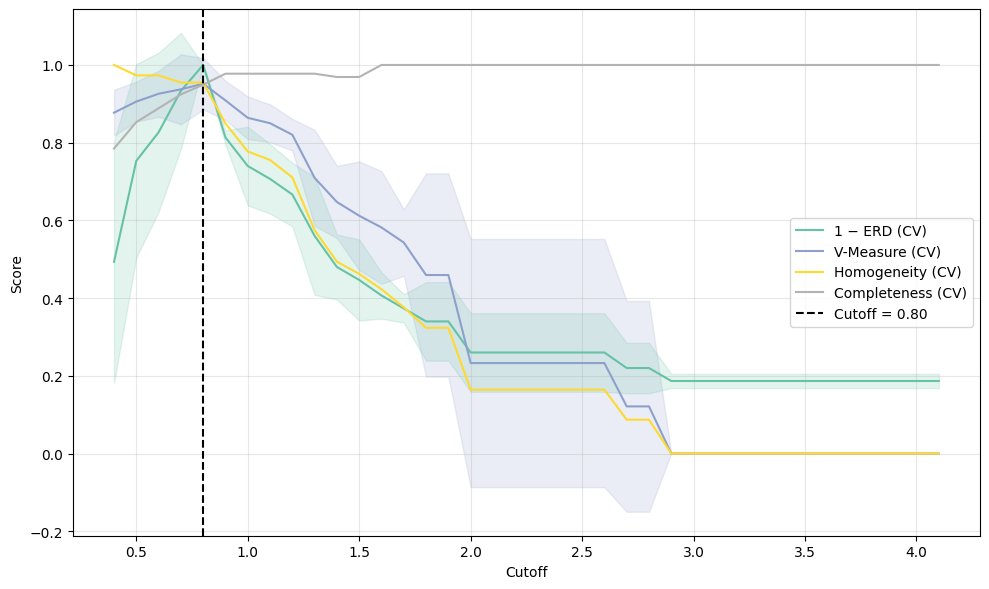

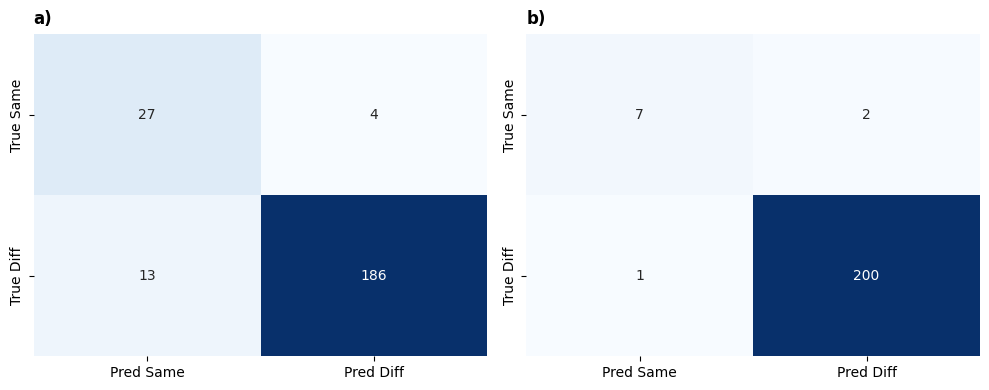

C:\Users\Frede\AppData\Local\Temp\ipykernel_13864\2339685319.py:146: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  line_colors = plt.cm.get_cmap(PALETTE_LINES, 4).colors


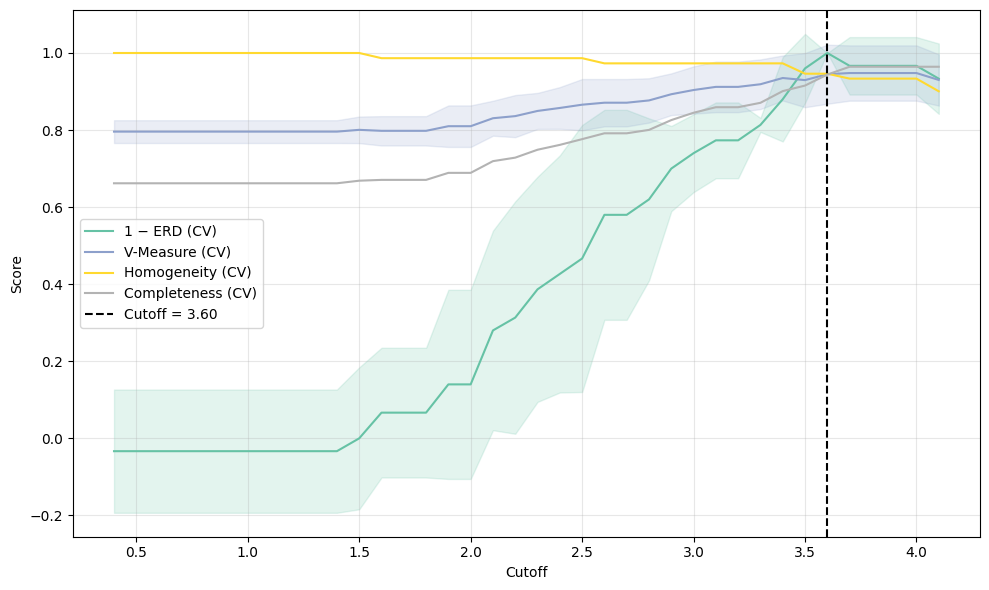

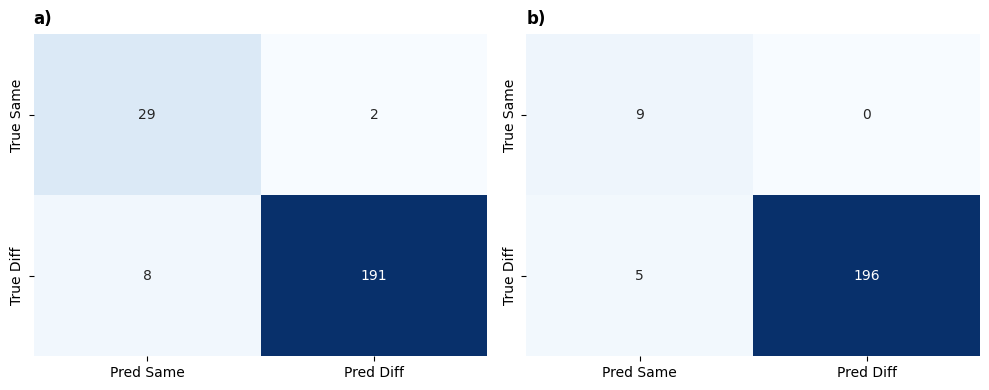

C:\Users\Frede\AppData\Local\Temp\ipykernel_13864\2339685319.py:146: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  line_colors = plt.cm.get_cmap(PALETTE_LINES, 4).colors


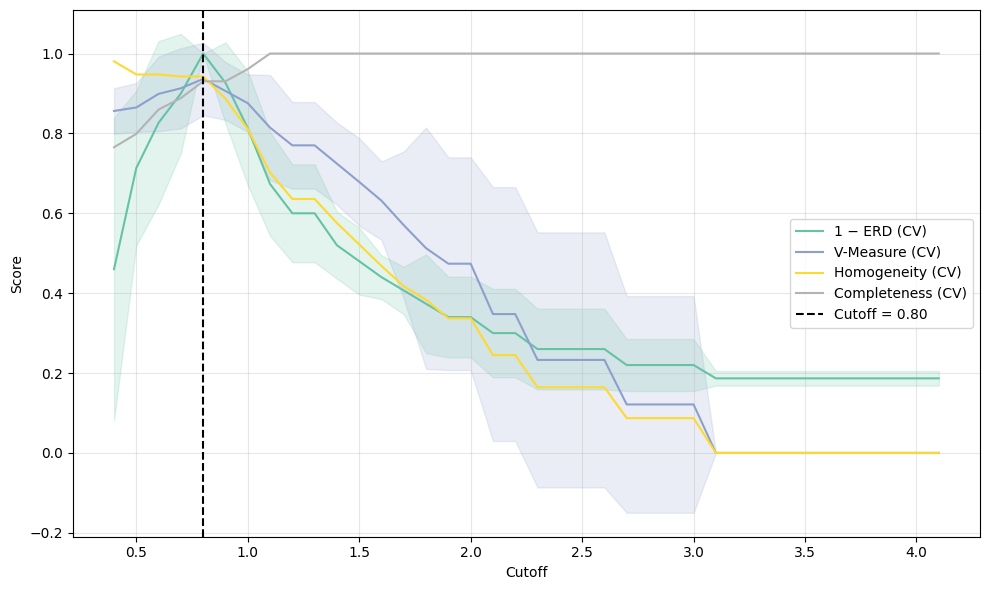

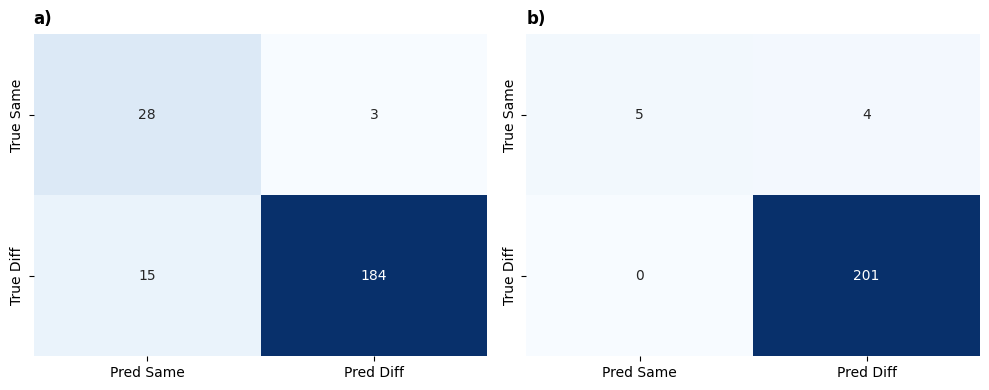

In [48]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

# =========================
# Paletten / Styles
# =========================
PALETTE_LINES = "Set2"    # für Cutoff-Kurven (Linien/Flaechen)
PALETTE_BARS  = "Dark2"   # für Barplots
HEATMAP_CMAP  = "Blues"    # für Confusion-Heatmaps

def panel_label(ax, text):
    ax.text(0.0, 1.02, text, transform=ax.transAxes,
            ha="left", va="bottom", fontsize=12, fontweight="bold")

# =========================
# Pfade
# =========================
combined_fp =  pd.read_csv(r"C:\Users\Frede\OneDrive\Projects and Disschaptors\FIT_package\notebooks\results\fit_notebook_final_final_123\results\individual_id\best_table_cluster_plus_classification.csv")
cutoff_curves_fp = pd.read_csv(r"C:\Users\Frede\OneDrive\Projects and Disschaptors\FIT_package\notebooks\results\fit_notebook_final_final_123\individual_id\benchmark_cutoff_curves_with_metrics.csv")

out_base     = cfg.PATHS["individual_id"]
otter_dir    = out_base / "otter_top3_plots"
overview_dir = out_base / "species_overview"
otter_dir.mkdir(parents=True, exist_ok=True)
overview_dir.mkdir(parents=True, exist_ok=True)

# =========================
# Laden
# =========================

# =========================
# Helpers
# =========================
def aggregate_curves(df):
    """Gruppiert pro Cutoff und liefert Mittel/Std für ERD, V, Hom, Comp."""
    m = (df.groupby("cutoff", as_index=False)
           .agg({"erd":["mean","std"], "v_measure":["mean","std"],
                 "homogeneity":["mean","std"], "completeness":["mean","std"]}))
    m.columns = ["cutoff","erd_mean","erd_std","v_mean","v_std","hom_mean","hom_std","comp_mean","comp_std"]
    return m

def build_cm_from_row(row, prefix):
    """Baut Confusion-Matrix aus vorhandenen Spalten; None falls nicht vorhanden."""
    keys = [f"clf__{prefix}true_same_pred_same",
            f"clf__{prefix}true_same_pred_diff",
            f"clf__{prefix}true_diff_pred_same",
            f"clf__{prefix}true_diff_pred_diff"]
    if not all(k in row.index for k in keys):
        return None
    return np.array([[row[keys[0]], row[keys[1]]],
                     [row[keys[2]], row[keys[3]]]], dtype=float)

def pick_present_metrics_from_row(row, candidates):
    """
    candidates: Liste von (colname, label)
    Gibt (labels, values) nur für vorhandene Spalten zurück.
    """
    labels, values = [], []
    for col, lab in candidates:
        if col in row.index and pd.notna(row[col]):
            labels.append(lab)
            values.append(float(row[col]))
    return labels, values

def get_cv_test_at_cutoff(curves_df, cutoff):
    """
    Liefert Test-Metriken am (oder nächstliegenden) Cutoff, falls 'origin' existiert und Test-Zeilen vorhanden sind;
    sonst NaN.
    """
    if "origin" not in curves_df.columns:
        return {"erd": np.nan, "v": np.nan, "hom": np.nan, "comp": np.nan}

    test_rows = curves_df[(curves_df["origin"] == "test") & (curves_df["cutoff"] == cutoff)]
    if test_rows.empty:
        test_rows = curves_df[curves_df["origin"] == "test"]
        if test_rows.empty:
            return {"erd": np.nan, "v": np.nan, "hom": np.nan, "comp": np.nan}
        # nächstliegender Cutoff
        test_rows = test_rows.iloc[(test_rows["cutoff"] - cutoff).abs().argsort()[:1]]

    t = test_rows.iloc[0]
    return {
        "erd": t.get("erd", np.nan),
        "v": t.get("v_measure", np.nan),
        "hom": t.get("homogeneity", np.nan),
        "comp": t.get("completeness", np.nan),
    }
curves = cutoff_df
dfp = curves.query("species == @species and tag == @tag and dist_col == @dist_col and preprocessing == @prep").copy()

# =========================
# 1) TOP-3 Pipelines für Otter
# =========================
otter = combined.query("species == 'eurasian_otter'").copy()
if otter.empty:
    raise ValueError("Keine Zeilen für species=='eurasian_otter' in der kombinierten Tabelle.")

# Ranking: cv_best_score (desc) → v_measure (desc) → erd (asc)
sort_cols = ["clust__cv_best_score", "clust__v_measure_mean", "clust__erd_mean"]
asc_flags = [False, False, True]
available_cols = [c for c in sort_cols if c in otter.columns]
if not available_cols:
    raise ValueError("Keine Ranking-Spalten gefunden (clust__cv_best_score / clust__v_measure_mean / clust__erd_mean).")

otter_top3 = (otter.sort_values(by=available_cols,
                                ascending=[asc_flags[sort_cols.index(c)] for c in available_cols])
                   .head(3)
                   .reset_index(drop=True))

# Übersicht der Top-3 speichern (nur vorhandene Spalten)
cols_top3 = [c for c in [
    "tag","clust__dist_col","clust__preprocessing","clust__cutoff",
    "clust__cv_best_score","clust__v_measure_mean","clust__erd_mean",
    "clf__cv_bal_acc","clf__test_bal_acc"
] if c in otter_top3.columns]
otter_top3_summary = otter_top3[cols_top3].copy()
otter_top3_summary.to_csv(otter_dir / "otter_top3_summary.csv", index=False)

# =========================
# 2) Visualisierung je Top-Pipeline
# =========================
for rank, row in otter_top3.iterrows():
    species = row["species"]
    tag     = row["tag"]
    dist_col= row["clust__dist_col"]
    prep    = row["clust__preprocessing"]
    cutoff  = float(row["clust__cutoff"])

    # --- Filter Kurven für genau diese Pipeline ---
    dfp = curves.query("species == @species and tag == @tag and dist_col == @dist_col and preprocessing == @prep").copy()
    if dfp.empty:
        print(f"⚠️ Keine Cutoff-Daten für: {tag} | {dist_col} | {prep}")
        continue

    # CV-Aggregate
    curves_cv = dfp[dfp["origin"] == "cv"] if "origin" in dfp.columns else dfp
    agg = aggregate_curves(curves_cv)
    # Test-Werte am Cutoff (falls vorhanden)
    test_at_cut = get_cv_test_at_cutoff(dfp, cutoff)

    # ---------- (a) Cutoff-Kurve ----------
    fig, ax = plt.subplots(figsize=(10,6))
    line_colors = plt.cm.get_cmap(PALETTE_LINES, 4).colors
    x = agg["cutoff"].to_numpy()

    # 1−ERD
    ax.plot(x, 1 - agg["erd_mean"], color=line_colors[0], label="1 − ERD (CV)")
    ax.fill_between(x, 1 - (agg["erd_mean"] + agg["erd_std"]),
                       1 - (agg["erd_mean"] - agg["erd_std"]),
                    color=line_colors[0], alpha=0.18)
    # V
    ax.plot(x, agg["v_mean"], color=line_colors[1], label="V-Measure (CV)")
    ax.fill_between(x, agg["v_mean"] - agg["v_std"],
                       agg["v_mean"] + agg["v_std"],
                    color=line_colors[1], alpha=0.18)
    # Hom / Comp
    ax.plot(x, agg["hom_mean"], color=line_colors[2], label="Homogeneity (CV)")
    ax.plot(x, agg["comp_mean"], color=line_colors[3], label="Completeness (CV)")

    ax.axvline(cutoff, linestyle="--", color="black", label=f"Cutoff = {cutoff:.2f}")
    ax.set_xlabel("Cutoff")
    ax.set_ylabel("Score")
    ax.legend()
    ax.grid(True, alpha=0.3)
    panel_label(ax, "")
    fig.tight_layout()
    fig.savefig(otter_dir / f"otter_TOP{rank+1}_{tag}_{dist_col}_{prep}_cutoff.png".replace(" ", "_"),
                dpi=300, bbox_inches="tight")
    plt.show()
    plt.close(fig)

    # ---------- (b) Confusion-Heatmaps ----------
    cm_cv = build_cm_from_row(row, "cv_")
    cm_te = build_cm_from_row(row, "test_")

    if cm_cv is not None or cm_te is not None:
        fig, axes = plt.subplots(1, 2, figsize=(10, 4))

        # --- CV (train) ---
        if cm_cv is not None:
            sns.heatmap(cm_cv, annot=True, fmt=".0f", cbar=False,
                        xticklabels=["Pred Same","Pred Diff"],
                        yticklabels=["True Same","True Diff"],
                        cmap=HEATMAP_CMAP, ax=axes[0])
            axes[0].set_xlabel(""); axes[0].set_ylabel("")
            panel_label(axes[0], "a)")  # <-- Label oben links
        else:
            axes[0].axis("off")

        # --- Test ---
        if cm_te is not None:
            sns.heatmap(cm_te, annot=True, fmt=".0f", cbar=False,
                        xticklabels=["Pred Same","Pred Diff"],
                        yticklabels=["True Same","True Diff"],
                        cmap=HEATMAP_CMAP, ax=axes[1])
            axes[1].set_xlabel(""); axes[1].set_ylabel("")
            panel_label(axes[1], "b)")  # <-- Label oben links
        else:
            axes[1].axis("off")

        fig.tight_layout()
        fig.savefig(
            otter_dir / f"otter_TOP{rank+1}_{tag}_{dist_col}_{prep}_confusion.png".replace(" ", "_"),
            dpi=300, bbox_inches="tight"
        )
        plt.show()
        plt.close(fig)


=== Top pipelines for Eurasian otter (by cv_best_score) ===


,species,tag,dist_col,preprocessing,cutoff,erd,v_measure,cv_best_score
0,eurasian_otter,forward_k8_sex,dist_cosine,raw,0.8,0.0,0.951691,0.975845
1,eurasian_otter,lasso_k12_sex,dist_manhattan,raw,3.6,0.0,0.944945,0.972473
2,eurasian_otter,forward_k6_sex,dist_cosine,raw,0.8,0.0,0.936318,0.968159


C:\Users\Frede\AppData\Local\Temp\ipykernel_13864\854916541.py:61: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  palette = plt.cm.get_cmap("tab10", 4).colors   # Alternativen: "Dark2", "tab10", "Set1", ...


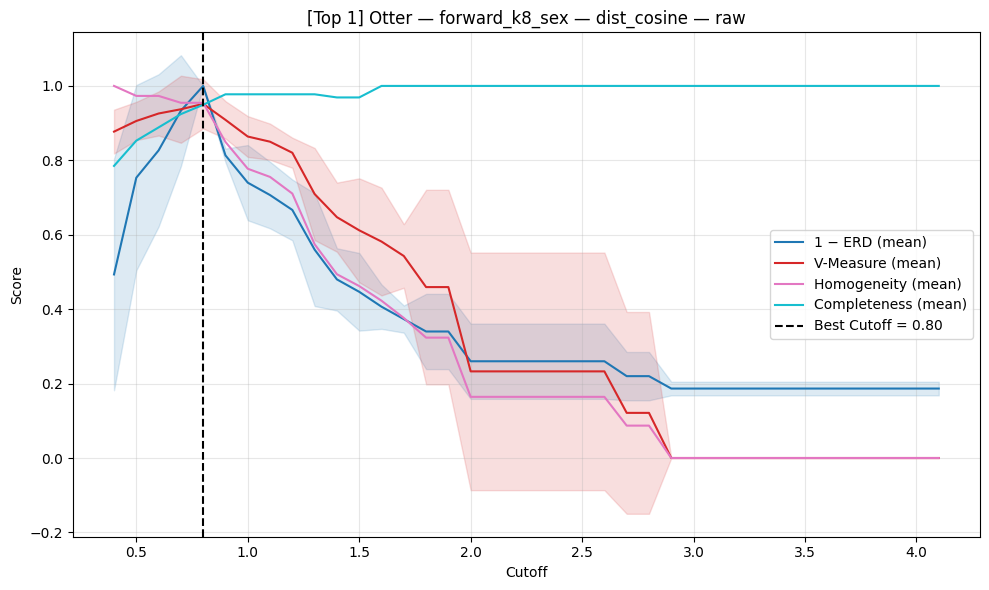

C:\Users\Frede\AppData\Local\Temp\ipykernel_13864\854916541.py:61: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  palette = plt.cm.get_cmap("tab10", 4).colors   # Alternativen: "Dark2", "tab10", "Set1", ...


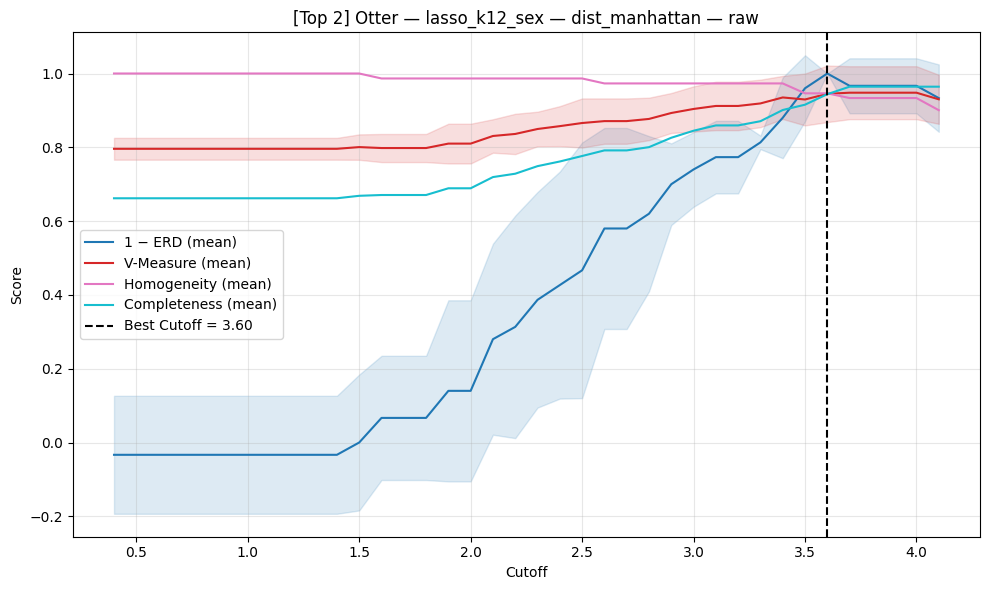

C:\Users\Frede\AppData\Local\Temp\ipykernel_13864\854916541.py:61: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  palette = plt.cm.get_cmap("tab10", 4).colors   # Alternativen: "Dark2", "tab10", "Set1", ...


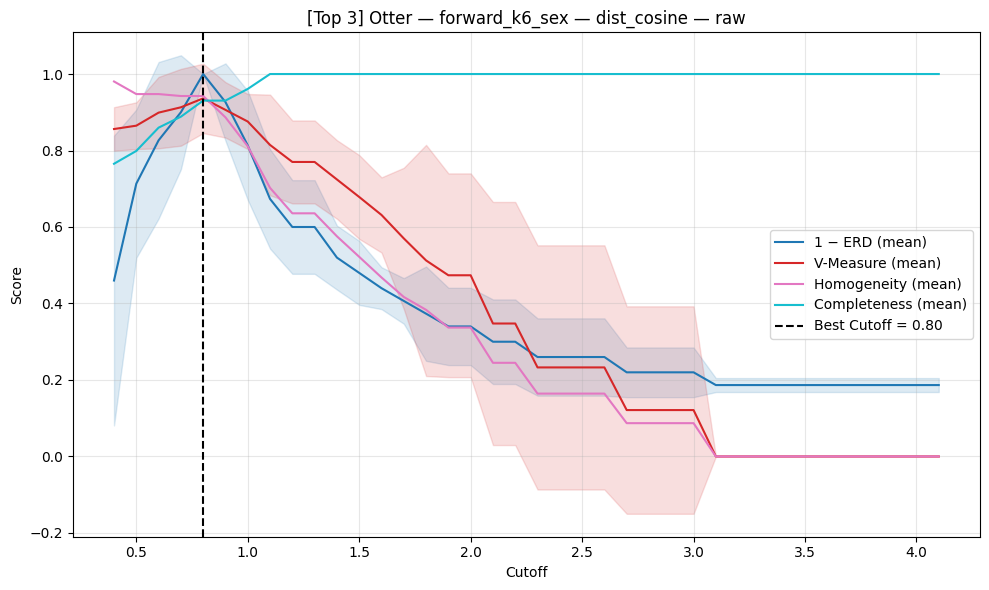

📊 Top-3 cutoff plots saved to: c:\Users\Frede\OneDrive\Projects and Disschaptors\FIT_package\notebooks\results\fit_notebook_final_final_123\results\individual_id\cutoff_plots_topk_otter


In [49]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from cycler import cycler

# --- Parameter ---
TOP_K = 3                             # wie viele Top-Pipelines plotten
SPECIES_KEY = "eurasian_otter"        # Species-Name wie in deinen DataFrames
out_base_dir = cfg.PATHS["individual_id"]
plot_dir = out_base_dir / "cutoff_plots_topk_otter"
plot_dir.mkdir(parents=True, exist_ok=True)

# --- Top-K Pipelines für Otter bestimmen (nach cv_best_score) ---
otter_best = (
    best_cutoffs
    .query("species == @SPECIES_KEY")
    .sort_values("cv_best_score", ascending=False)
    .reset_index(drop=True)
)

if otter_best.empty:
    raise ValueError("No best_cutoffs rows found for species == 'eurasian_otter'.")

top_rows = otter_best.head(TOP_K)

print("=== Top pipelines for Eurasian otter (by cv_best_score) ===")
display(top_rows[["species","tag","dist_col","preprocessing","cutoff","erd","v_measure","cv_best_score"]])

# --- Für jede Top-Pipeline die Cutoff-Kurve plotten ---
for rank, row in top_rows.reset_index().iterrows():
    species = row["species"]
    tag = row["tag"]
    dist_col = row["dist_col"]
    prep = row["preprocessing"]
    best_cutoff = float(row["cutoff"])

    df_plot = cutoff_df.query(
        "species == @species and tag == @tag and dist_col == @dist_col and preprocessing == @prep"
    )
    if df_plot.empty:
        print(f"⚠️ No cutoff data for {species}, {tag}, {dist_col}, {prep} — skipping.")
        continue

    mean_scores_plot = (
        df_plot.groupby("cutoff", as_index=False)
        .agg({
            "erd": ["mean","std"],
            "homogeneity": ["mean","std"],
            "completeness": ["mean","std"],
            "v_measure": ["mean","std"],
            "cv_best_score": ["mean","std"],
        })
    )
    mean_scores_plot.columns = [
        "cutoff","erd_mean","erd_std","hom_mean","hom_std",
        "comp_mean","comp_std","v_mean","v_std","score_mean","score_std"
    ]

    # Wähle eine Matplotlib-Palette und genau 4 Farben (1−ERD, V, Hom, Comp)
    palette = plt.cm.get_cmap("tab10", 4).colors   # Alternativen: "Dark2", "tab10", "Set1", ...

    fig, ax = plt.subplots(figsize=(10, 6))
    ax.set_prop_cycle(cycler(color=palette))

    x = mean_scores_plot["cutoff"].to_numpy()

    # 1 − ERD (mean) + Fehlerband
    l1, = ax.plot(x, 1 - mean_scores_plot["erd_mean"], label="1 − ERD (mean)")
    ax.fill_between(
        x,
        1 - (mean_scores_plot["erd_mean"] + mean_scores_plot["erd_std"]),
        1 - (mean_scores_plot["erd_mean"] - mean_scores_plot["erd_std"]),
        color=l1.get_color(), alpha=0.15
    )

    # V-Measure (mean) + Fehlerband
    l2, = ax.plot(x, mean_scores_plot["v_mean"], label="V-Measure (mean)")
    ax.fill_between(
        x,
        mean_scores_plot["v_mean"] - mean_scores_plot["v_std"],
        mean_scores_plot["v_mean"] + mean_scores_plot["v_std"],
        color=l2.get_color(), alpha=0.15
    )

    # Homogeneity & Completeness (nur Linien)
    ax.plot(x, mean_scores_plot["hom_mean"], label="Homogeneity (mean)")
    ax.plot(x, mean_scores_plot["comp_mean"], label="Completeness (mean)")

    # Best Cutoff
    ax.axvline(best_cutoff, color="black", linestyle="--",
            label=f"Best Cutoff = {best_cutoff:.2f}")

    # Achsen/Titel/Legende
    ax.set_xlabel("Cutoff")
    ax.set_ylabel("Score")
    ax.set_title(f"[Top {rank+1}] Otter — {tag} — {dist_col} — {prep}")
    ax.legend()
    ax.grid(True, alpha=0.3)
    fig.tight_layout()

    # Speichern/anzeigen
    filename = f"otter_TOP{rank+1}_{tag}_{dist_col}_{prep}_cutoff_plot.png".replace(" ", "_")
    fig.savefig(plot_dir / filename, dpi=300, bbox_inches="tight")
    plt.show()
    plt.close(fig)

print(f"📊 Top-{TOP_K} cutoff plots saved to: {plot_dir}")


=== Fold 0 ===


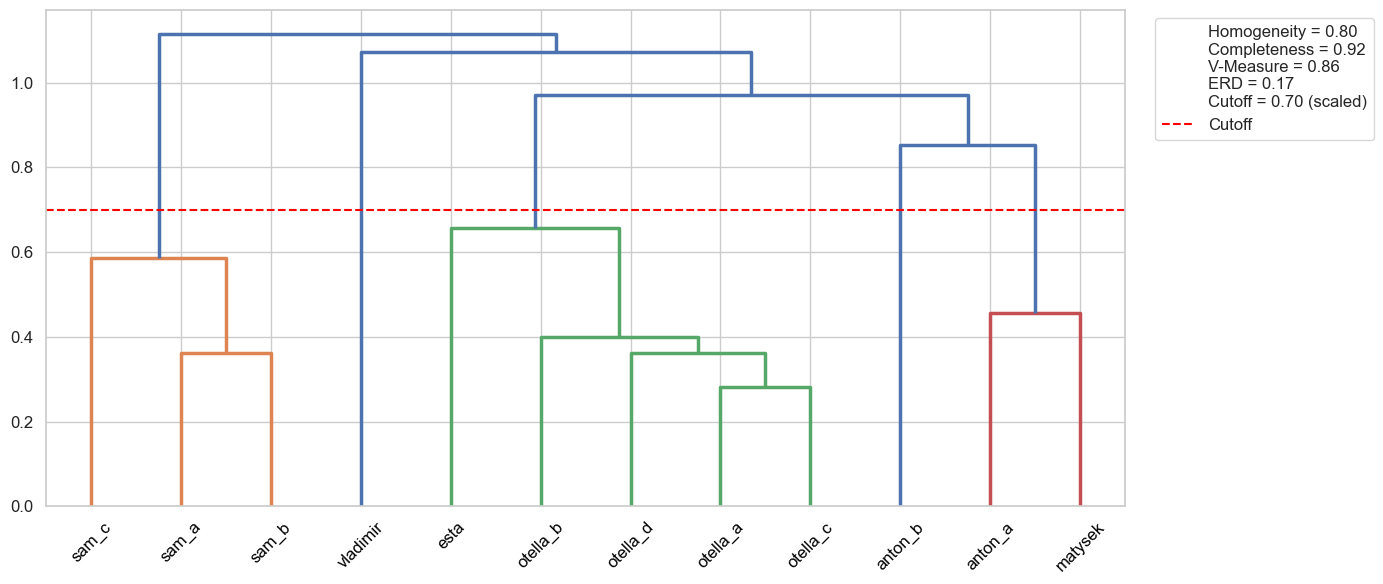

=== Fold 1 ===


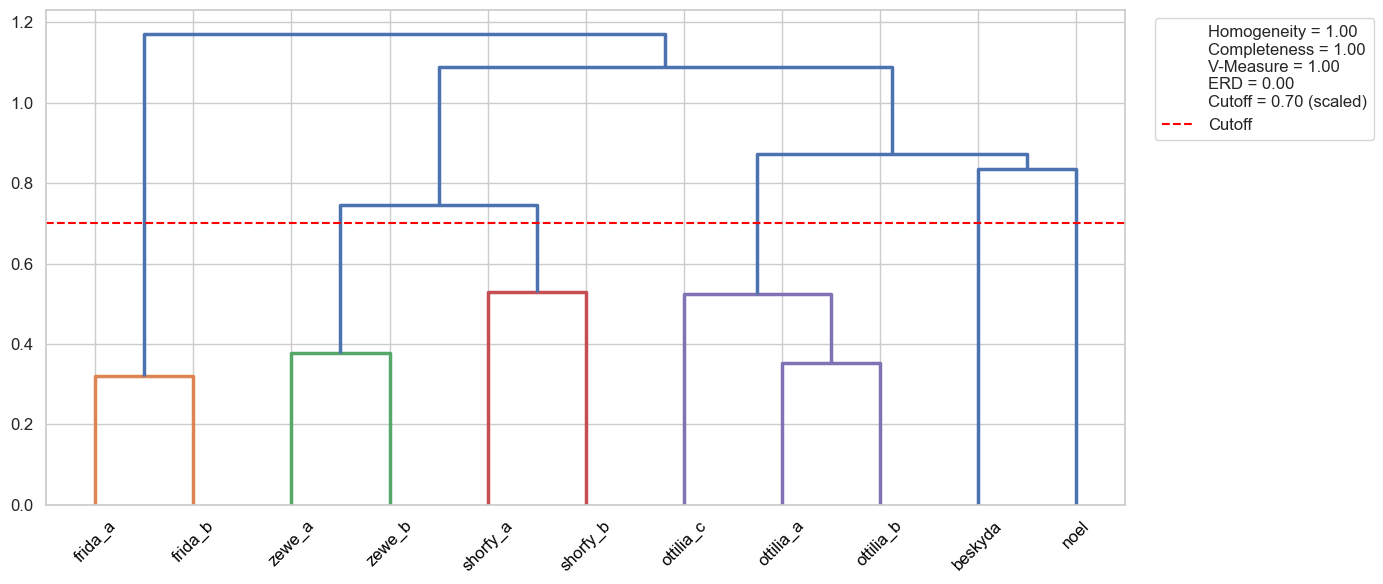

=== Fold 2 ===


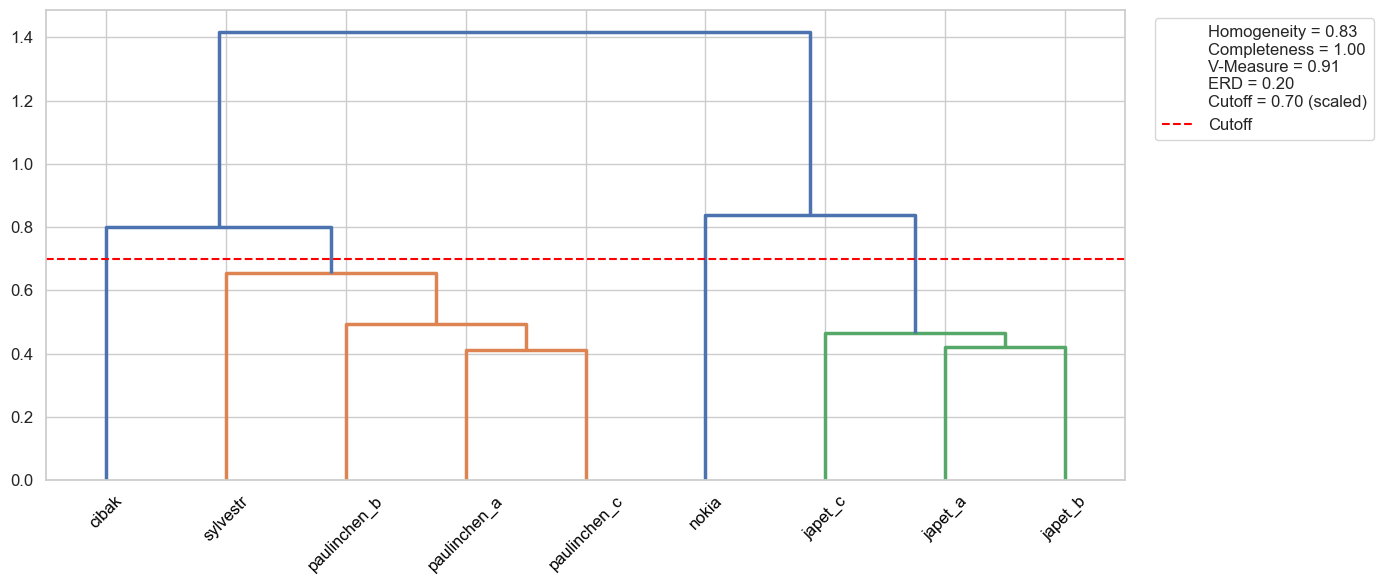

=== Fold 3 ===


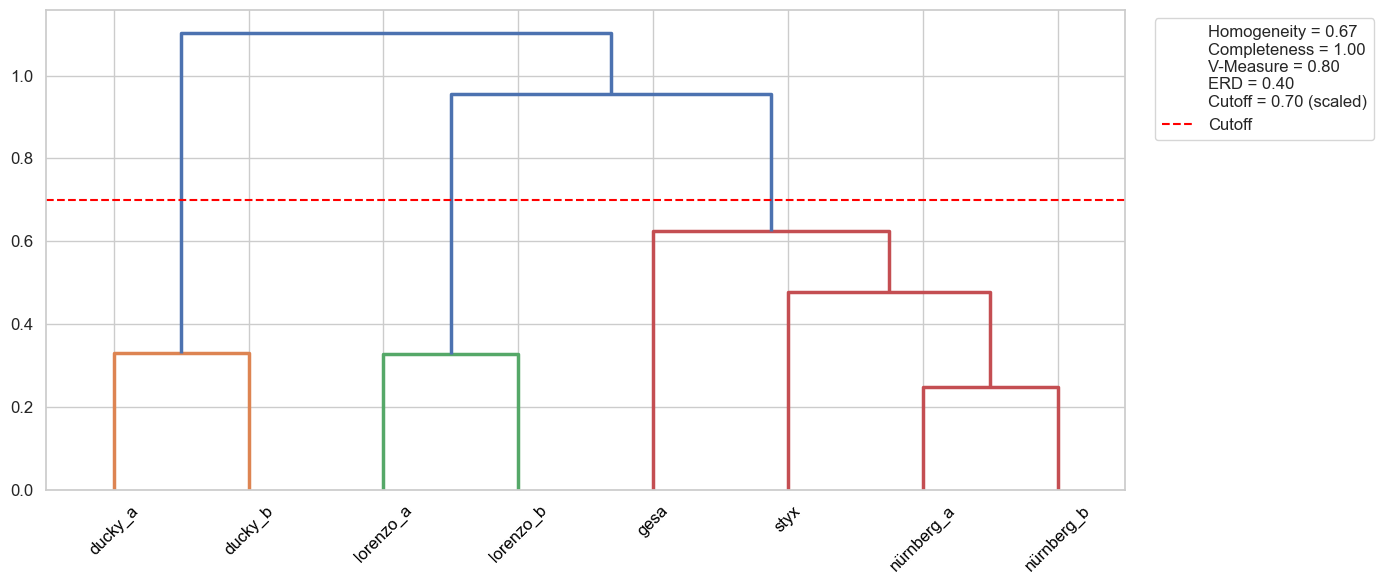

=== Fold 4 ===


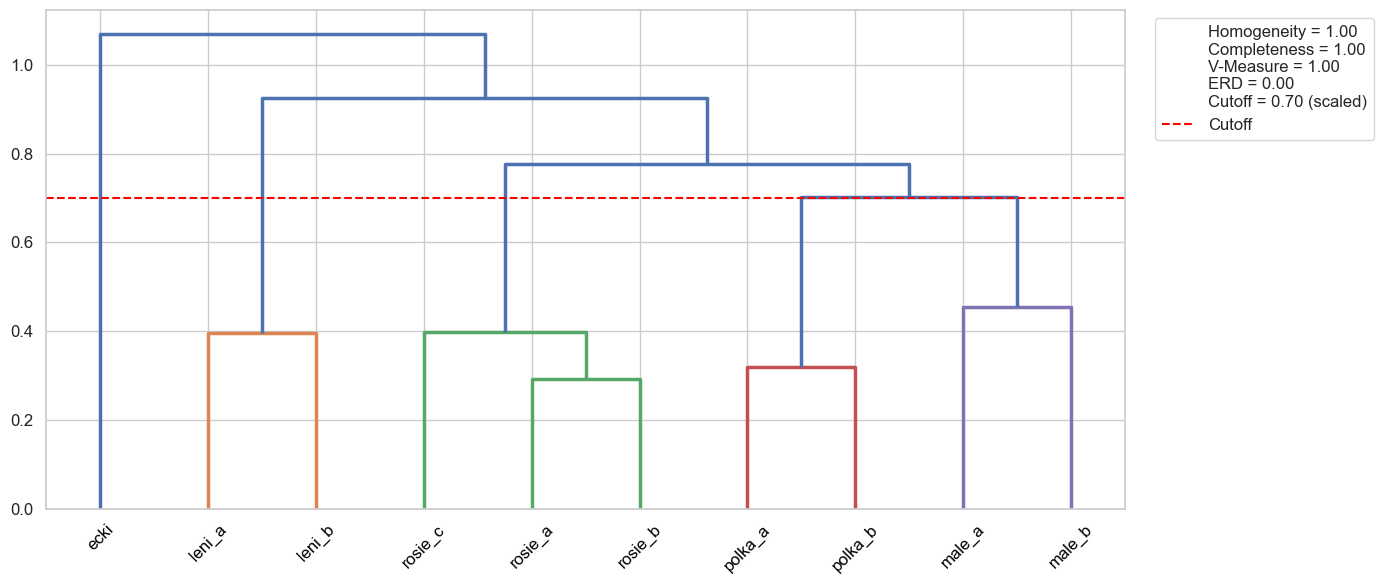

In [54]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.cluster.hierarchy import linkage, dendrogram, fcluster
from scipy.spatial.distance import squareform
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import homogeneity_score, completeness_score, v_measure_score
import matplotlib as mpl
from FIT_python import config as cfg
import re


# --- Master-Pairs laden ---
df_master = pd.read_csv(r"C:\Users\Frede\OneDrive\Projects and Disschaptors\FIT_package\notebooks\results\fit_notebook_final_final_123\results\individual_id\eurasian_otter\eurasian_otter_master_pairs.csv")

# Filter nach Pipeline + ohne "unknown"-Trails
df_filtered = (
    df_master[df_master["pipeline"] == "lasso_no_out_standard_k12_lda_nc2_sex_on"]
    .query("trail_a_id != 'unknown' and trail_b_id != 'unknown'")
    .copy()
)
dist_col = "dist_manhattan"
df = df_filtered

def plot_dendrogram(df_sub, cutoff=3.6, scaled=False):
    from matplotlib.lines import Line2D

    # Trails sammeln
    trails = sorted({*df_sub["trail_a_id"], *df_sub["trail_b_id"]})
    D = pd.DataFrame(np.nan, index=trails, columns=trails, dtype=float)
    for a, b, d in zip(df_sub["trail_a_id"], df_sub["trail_b_id"], df_sub[dist_col]):
        D.at[a, b] = D.at[b, a] = d
    np.fill_diagonal(D.values, 0.0)

    # NaNs konservativ mit max füllen (wie bisher)
    raw_max = np.nanmax(D.values)
    D = D.fillna(raw_max)

    # --- Scaling + Cutoff in passende Einheit bringen ---
    if scaled:
        D_values = D.values / raw_max  # MinMax: min=0 wegen Diagonale, daher einfach /max
        # Wenn Cutoff > 1, interpretieren wir ihn als "raw" und skalieren ihn runter
        cutoff_plot = cutoff / raw_max if cutoff > 1 else cutoff
    else:
        D_values = D.values
        cutoff_plot = cutoff

    # Clustering
    condensed = squareform(D_values, checks=False)
    link = linkage(condensed, method="ward")
    cluster_labels = fcluster(link, t=cutoff_plot, criterion="distance")

    # Wahre Labels
    trail_to_true = {**dict(zip(df_sub["trail_a_id"], df_sub["ind_a"])),
                     **dict(zip(df_sub["trail_b_id"], df_sub["ind_b"]))}
    true_labels = [trail_to_true[t] for t in trails]

    # Labels säubern (dein Code)
    remove_words = ["hankensbüttel","female","pforzheim","naturoparc","naturopark",
                    "nuturopark","salzburg","wiesbaden"]
    def clean_label(label):
        parts = [p for p in label.split("_") if p.lower() not in remove_words]
        label_clean = "_".join(parts)
        gen_match = re.search(r"gen(?:etik_probe_)?(\d+(?:[_-]\d+)*)", label_clean.lower())
        if gen_match:
            gen_id = gen_match.group(1).replace("_","-").upper()
            return f"GEN{gen_id}"
        short = "_".join(label_clean.split("_")[-2:])
        return short if short else label_clean
    short_labels = [clean_label(t) for t in trails]

    # Plot
    fig, ax = plt.subplots(figsize=(14, 6))
    dendro = dendrogram(link, labels=short_labels, leaf_rotation=45, color_threshold=cutoff_plot)

    # Achsen-Formatierung + sinnvolle y-Limits (nicht durch Cutoff-Linie aufblasen lassen)
    ax.set_ylim(0, link[:, 2].max() * 1.05)
    tick_size = (ax.xaxis.get_ticklabels()[0].get_size()
                 if ax.xaxis.get_ticklabels() else 10)
    plt.setp(ax.get_xticklabels(), color="black", fontsize=tick_size, rotation=45)
    plt.setp(ax.get_yticklabels(), fontsize=tick_size)
    plt.setp(ax.collections, linewidth=2.5)

    # Cutoff-Linie in korrekter Einheit
    cutoff_line = ax.axhline(y=cutoff_plot, color="red", linestyle="--", label="Cutoff")

    # Metriken
    h = homogeneity_score(true_labels, cluster_labels)
    c = completeness_score(true_labels, cluster_labels)
    v = v_measure_score(true_labels, cluster_labels)
    erd = abs(len(set(cluster_labels)) - len(set(true_labels))) / len(set(true_labels))

    metrics_text = (f"Homogeneity = {h:.2f}\n"
                    f"Completeness = {c:.2f}\n"
                    f"V-Measure = {v:.2f}\n"
                    f"ERD = {erd:.2f}\n"
                    f"Cutoff = {cutoff_plot:.2f}"
                    f"{' (scaled)' if scaled else ''}")

    dummy = Line2D([], [], color="none")
    ax.legend([dummy, cutoff_line], [metrics_text, "Cutoff"],
              loc="upper left", bbox_to_anchor=(1.02, 1), fontsize=tick_size,
              frameon=True, fancybox=True)

    fig.tight_layout()
    plt.show()



# --- CV Folds ---
for fold in sorted(df["fold"].dropna().unique()):
    df_fold = df[(df["origin"] == "cv") & (df["fold"] == fold)].copy()
    print(f"=== Fold {int(fold)} ===")
    plot_dendrogram(df_fold, cutoff=0.7, scaled=True)

# --- Testset ---
df_test = df[df["origin"] == "test"].copy()
if not df_test.empty:
    print("=== Testset ===")
    plot_dendrogram(df_test, cutoff=3.6, scaled=False)


In [51]:
import pandas as pd
from FIT_python.pipeline_individual_id import sequential_holdout
from FIT_python.config import CONFIG
from FIT_python import config

# -----------------------------------------------------------
# 1) Parameter festlegen
# -----------------------------------------------------------
k = 12                                  # Anzahl der zu verwendenden Features
selection_method = "lasso"              # 'forward', 'random_forest', 'variance', 'univariate', 'lasso' oder None
use_sex = True                          # True → Sexmodell einbinden, False → ohne

CONFIG["pipeline_individual_id"]["pairwise_defaults"]["selection_method"] = selection_method

out_base_dir = cfg.PATHS["individual_id"]

# -----------------------------------------------------------
# 2) Otter‑Splits laden
# -----------------------------------------------------------
splits_dir = config.SPLITS_DIR / "eurasian_otter"
train_df = pd.read_parquet(splits_dir / "train.parquet")
test_df  = pd.read_parquet(splits_dir / "test.parquet")

# morphometrische Feature‑Spalten bestimmen
feature_cols = [
    c for c in train_df.columns
    if c.startswith(("dist", "ang", "t", "v")) and c not in ["trail"]
]

# Pfad zum Sexmodell (nur benötigt, wenn use_sex=True)
#sex_model = str(config.PATHS["random_search"] / "best_mean_rank" / "eurasian_otter.joblib")

sexmodel_path = config.PATHS["sex_modelling"] / "eurasian_otter" / "models" / "balanced_accuracy" / "eurasian_otter.joblib"

# -----------------------------------------------------------
# 3) Sequential Holdout – Training (mehrere Val-Größen)
# -----------------------------------------------------------
train_summary = sequential_holdout.run(
    df=train_df,
    feature_cols=feature_cols,
    iterations=30,
    val_sizes=[2,3, 4,5, 6,7, 8,9, 10,11, 12,13, 14,15, 16,17,18,19,20],
    k_features=k,
    use_sexmodel_prediction=use_sex,      # muss True sein, damit sexmodel_path genutzt wird
    sexmodel_path=sexmodel_path,          # <— KOMMA hier!
    out_dir=out_base_dir / "eurasian_otter_train_final"
)

# -----------------------------------------------------------
# 4) Sequential Holdout – Test (eine Val-Gruppe = ganzer Testsplit)
# -----------------------------------------------------------
test_summary = sequential_holdout.run(
    df=test_df,
    feature_cols=feature_cols,
    iterations=1,
    val_sizes=[len(test_df["individual_id"].unique())],
    k_features=k,
    use_sexmodel_prediction=use_sex,
    sexmodel_path=sexmodel_path,          # <— KOMMA hier!
    out_dir=out_base_dir / "individual_id" / "eurasian_otter_test_final"
)

display(train_summary)
display(test_summary)


Processing Pairs:   0%|          | 0/10 [00:00<?, ?it/s]

  0%|          | 0/10 [00:00<?, ?it/s]

Processing Pairs:   0%|          | 0/21 [00:00<?, ?it/s]

  0%|          | 0/21 [00:00<?, ?it/s]

Processing Pairs:   0%|          | 0/36 [00:00<?, ?it/s]

...

  0%|          | 0/703 [00:00<?, ?it/s]

  0%|          | 0/210 [00:00<?, ?it/s]

C:\Users\Frede\OneDrive\Projects and Disschaptors\FIT_package\src\FIT_python\pipeline_individual_id\population_estimation.py:125: RuntimeWarning: Degrees of freedom <= 0 for slice
  var_x = x.var(ddof=1)
C:\Users\Frede\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\numpy\_core\_methods.py:215: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
C:\Users\Frede\OneDrive\Projects and Disschaptors\FIT_package\src\FIT_python\pipeline_individual_id\population_estimation.py:126: RuntimeWarning: Degrees of freedom <= 0 for slice
  var_y = y.var(ddof=1)
C:\Users\Frede\OneDrive\Projects and Disschaptors\FIT_package\src\FIT_python\pipeline_individual_id\population_estimation.py:127: RuntimeWarning: Degrees of freedom <= 0 for slice
  cov_xy = np.cov(x, y, ddof=1)[0, 1]
C:\Users\Frede\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-pack

,split,iteration,n_val,bcr,pred_count,true_count,erd,ward_cutoff,cutoff_low,cutoff_high,tp,fp,tn,fn,n_pairs,ccc
0,0,0,2,0.500000,2,2,0.0,4.497291,4.311192,4.683391,0,0,6,4,10,1.0
1,1,0,3,0.800000,3,3,0.0,2.774159,2.725149,2.823169,3,0,16,2,21,1.0
2,2,0,4,0.839901,4,4,0.0,3.220375,2.975916,3.464835,5,1,28,2,36,1.0
3,3,0,5,0.634309,5,5,0.0,2.605907,2.431483,2.780331,3,5,42,5,55,1.0
4,4,0,6,0.866379,6,6,0.0,3.074192,2.836480,3.311905,6,1,57,2,66,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
565,565,29,16,0.681748,16,16,0.0,2.653523,2.605579,2.701467,11,22,479,16,528,1.0
566,566,29,17,0.679339,17,17,0.0,2.765876,2.627384,2.904368,10,25,580,15,630,1.0
567,567,29,18,0.672099,18,18,0.0,3.182811,3.161933,3.203690,11,25,687,18,741,1.0
568,568,29,19,0.626765,19,19,0.0,2.891811,2.870673,2.912950,6,11,562,16,595,1.0


,split,iteration,n_val,bcr,pred_count,true_count,erd,ward_cutoff,cutoff_low,cutoff_high,tp,fp,tn,fn,n_pairs,ccc
0,0,0,13,0.5,13,13,0.0,9.928836,9.436333,10.421339,0,0,199,11,210,NaN


In [52]:
import numpy as np
import pandas as pd
from pathlib import Path
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import homogeneity_score, completeness_score, v_measure_score
from joblib import Parallel, delayed
from tqdm import tqdm
from scipy.spatial.distance import squareform
from scipy.cluster.hierarchy import linkage, fcluster

from FIT_python.pipeline_individual_id.population_estimation import compute_erd
from FIT_python import config as cfg

# === Parameter ===
species = "eurasian_otter"
alpha = 0.5  # Gewichtung: 0.5 = gleichgewichtet ERD und V-Measure
cutoff_range = np.arange(0.4, 4.2, 0.05)
base_metrics = [
    "euclidean", "manhattan", "cosine",
    "chebyshev", "canberra", "braycurtis"
]

# === Pfade ===
train_fp = cfg.PATHS["individual_id"] / "eurasian_otter_train_final" / "all_splits.csv"
out_dir = cfg.PATHS["individual_id"] / "sequential"
out_dir.mkdir(parents=True, exist_ok=True)

# === Daten laden ===
df_train = pd.read_csv(train_fp)
df_train = df_train[
    ~(df_train["trail_a_id"].str.strip().eq("unknown") |
      df_train["trail_b_id"].str.strip().eq("unknown"))
]

# === Alle Distanzmetriken extrahieren ===
between_cols = [c for c in df_train.columns if "between" in c]
metrics = [f"dist_{m}" for m in base_metrics] + between_cols

# === Hilfsfunktion für Clustering und Evaluation ===
def evaluate_clusters(D, true_labels, cutoff):
    condensed = squareform(D.to_numpy(), checks=False)
    link = linkage(condensed, method="ward")
    cluster_labels = fcluster(link, t=cutoff, criterion="distance")

    h = homogeneity_score(true_labels, cluster_labels)
    c = completeness_score(true_labels, cluster_labels)
    v = v_measure_score(true_labels, cluster_labels)
    return cluster_labels, h, c, v

# === Hauptfunktion pro Kombination ===
def process_combination(species, tag, dist_col, prep, df_tag):
    trails = sorted({*df_tag["trail_a_id"], *df_tag["trail_b_id"]})
    D = pd.DataFrame(np.nan, index=trails, columns=trails)
    for a, b, d in zip(df_tag["trail_a_id"], df_tag["trail_b_id"], df_tag[dist_col]):
        D.at[a, b] = D.at[b, a] = d
    np.fill_diagonal(D.values, 0.0)
    D = D.fillna(D.values.max())

    if prep == "minmax":
        D[:] = MinMaxScaler().fit_transform(D)

    label_map = {}
    label_map.update(df_tag.set_index("trail_a_id")["ind_a"].to_dict())
    label_map.update(df_tag.set_index("trail_b_id")["ind_b"].to_dict())
    true_labels = [str(label_map[t]) for t in trails]
    true_n = len(np.unique(true_labels))

    recs = []
    for cutoff in cutoff_range:
        cluster_labels, h, c, v = evaluate_clusters(D, true_labels, cutoff)
        pred_n = len(np.unique(cluster_labels))
        erd = compute_erd(pred_n, true_n)
        score = alpha * (1 - erd) + (1 - alpha) * v
        recs.append({
            "species": species,
            "tag": tag,
            "dist_col": dist_col,
            "preprocessing": prep,
            "cutoff": cutoff,
            "erd": erd,
            "pred_n": pred_n,
            "true_n": true_n,
            "homogeneity": h,
            "completeness": c,
            "v_measure": v,
            "score": score
        })

    cut_df = pd.DataFrame(recs)
    best = cut_df.loc[cut_df["erd"].idxmin()]
    return {**best.to_dict(), "status": "ok", "cut_df": cut_df}

# === TASKS vorbereiten ===
all_tasks = []
print("Spalten im DataFrame:", df_train.columns.tolist())

for tag, df_tag in df_train.groupby("split"):
    for dist_col in metrics:
        if dist_col not in df_tag.columns:
            continue
        for prep in ["raw", "minmax"]:
            all_tasks.append((species, tag, dist_col, prep, df_tag))

print(f"Gesammelte Tasks: {len(all_tasks)}")

# === Berechnung starten ===
print("Starte Verarbeitung …")
results = Parallel(n_jobs=-1)(
    delayed(process_combination)(*task) for task in tqdm(all_tasks)
)

# === Ergebnisse speichern ===
records, cutoff_records = [], []
for res in results:
    cutoff_records.append(res.pop("cut_df"))
    records.append(res)

benchmark_df = pd.DataFrame(records)
benchmark_df.to_csv(out_dir / "eurasian_otter_train_sequential_holdout_final.csv", index=False)

if cutoff_records:
    cutoff_df = pd.concat(cutoff_records, ignore_index=True)
    cutoff_df.to_csv(out_dir / "eurasian_otter_train_cutoff_curves_final.csv", index=False)

# === Ausgabe ===
print("=== Benchmark Summary ===")
display(benchmark_df)
if cutoff_records:
    display(cutoff_df)


Spalten im DataFrame: ['trail_a_id', 'trail_b_id', 'samples_a', 'samples_b', 'ind_a', 'ind_b', 'same_individual', 'fold', 'pipeline', 'selection_method', 'reducer', 'outlier_method', 'scaler_method', 'k_features', 'n_components', 'comparison_id', 'min_observations', 'max_observations', 'use_sexmodel_prediction', 'avg_proba_A_0', 'avg_proba_A_1', 'avg_proba_B_0', 'avg_proba_B_1', 'avg_proba_R_0', 'avg_proba_R_1', 'center_a_x', 'center_a_y', 'center_b_x', 'center_b_y', 'center_r_x', 'center_r_y', 'coords_a_x', 'coords_a_y', 'coords_b_x', 'coords_b_y', 'coords_r_x', 'coords_r_y', 'selected_features', 'selected_scores', 'dist_euclidean', 'mean_euclidean_between', 'median_euclidean_between', 'mean_euclidean_within_a', 'median_euclidean_within_a', 'mean_euclidean_within_b', 'median_euclidean_within_b', 'dist_manhattan', 'mean_manhattan_between', 'median_manhattan_between', 'mean_manhattan_within_a', 'median_manhattan_within_a', 'mean_manhattan_within_b', 'median_manhattan_within_b', 'dist_co

100%|██████████| 20520/20520 [06:17<00:00, 54.42it/s]


=== Benchmark Summary ===


,species,tag,dist_col,preprocessing,cutoff,erd,pred_n,true_n,homogeneity,completeness,v_measure,score,status
0,eurasian_otter,0,dist_euclidean,raw,1.95,0.00,2,2,1.000000,1.000000,1.000000,1.000000,ok
1,eurasian_otter,0,dist_euclidean,minmax,0.55,0.00,2,2,1.000000,1.000000,1.000000,1.000000,ok
2,eurasian_otter,0,dist_manhattan,raw,2.30,0.00,2,2,1.000000,1.000000,1.000000,1.000000,ok
3,eurasian_otter,0,dist_manhattan,minmax,0.50,0.00,2,2,1.000000,1.000000,1.000000,1.000000,ok
4,eurasian_otter,0,dist_cosine,raw,0.50,0.00,2,2,1.000000,1.000000,1.000000,1.000000,ok
...,...,...,...,...,...,...,...,...,...,...,...,...,...
20515,eurasian_otter,569,median_canberra_between,minmax,0.65,0.15,17,20,0.812153,0.842190,0.826899,0.838449,ok
20516,eurasian_otter,569,mean_braycurtis_between,raw,0.80,0.05,21,20,0.912550,0.885301,0.898719,0.924359,ok
20517,eurasian_otter,569,mean_braycurtis_between,minmax,0.40,0.35,13,20,0.762249,0.883618,0.818458,0.734229,ok
20518,eurasian_otter,569,median_braycurtis_between,raw,0.70,0.05,21,20,0.930382,0.902601,0.916281,0.933141,ok


,species,tag,dist_col,preprocessing,cutoff,erd,pred_n,true_n,homogeneity,completeness,v_measure,score
0,eurasian_otter,0,dist_euclidean,raw,0.40,1.00,4,2,1.0,0.5,0.666667,0.333333
1,eurasian_otter,0,dist_euclidean,raw,0.45,1.00,4,2,1.0,0.5,0.666667,0.333333
2,eurasian_otter,0,dist_euclidean,raw,0.50,1.00,4,2,1.0,0.5,0.666667,0.333333
3,eurasian_otter,0,dist_euclidean,raw,0.55,1.00,4,2,1.0,0.5,0.666667,0.333333
4,eurasian_otter,0,dist_euclidean,raw,0.60,1.00,4,2,1.0,0.5,0.666667,0.333333
...,...,...,...,...,...,...,...,...,...,...,...,...
1559515,eurasian_otter,569,median_braycurtis_between,minmax,3.95,0.95,1,20,0.0,1.0,0.000000,0.025000
1559516,eurasian_otter,569,median_braycurtis_between,minmax,4.00,0.95,1,20,0.0,1.0,0.000000,0.025000
1559517,eurasian_otter,569,median_braycurtis_between,minmax,4.05,0.95,1,20,0.0,1.0,0.000000,0.025000
1559518,eurasian_otter,569,median_braycurtis_between,minmax,4.10,0.95,1,20,0.0,1.0,0.000000,0.025000


🔎 Top 3 Kombinationen über alle Splits:
           dist_col preprocessing  cutoff       erd  v_measure    score
728  dist_euclidean           raw     2.6  0.100517   0.931838  0.91566


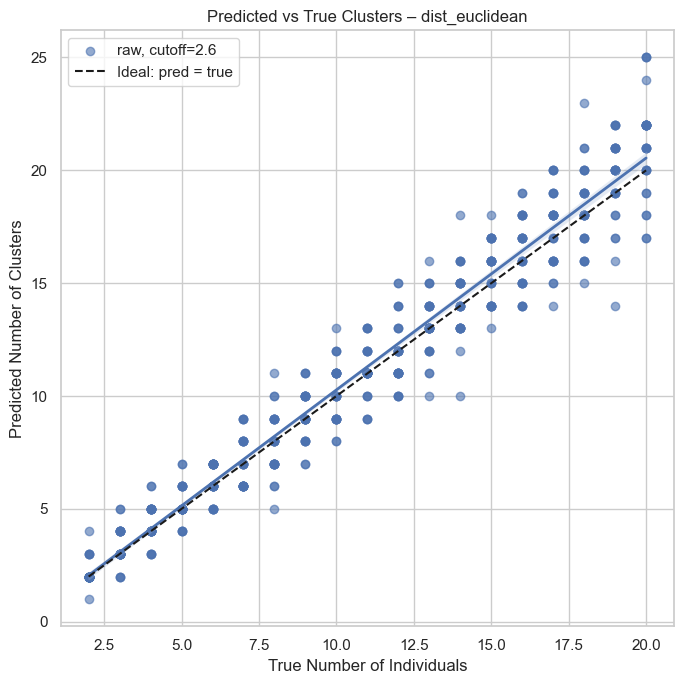

In [56]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# === Parameter ===
cutoff_fp = out_dir / "eurasian_otter_train_cutoff_curves_final.csv"
alpha = 0.5  # Gewichtung: 0.5 = gleichgewichtet ERD und V-Measure

# === CSV einlesen ===
cutoff_df = pd.read_csv(cutoff_fp)

# === Mittelwerte pro (dist_col, preprocessing, cutoff) berechnen ===
agg_df = (
    cutoff_df
    .groupby(["dist_col", "preprocessing", "cutoff"])[["erd", "v_measure"]]
    .mean()
    .reset_index()
)

# === Score berechnen ===
agg_df["score"] = alpha * (1 - agg_df["erd"]) + (1 - alpha) * agg_df["v_measure"]

# === Top-3 Kombinationen mit höchsten Scores
top3_combos = agg_df.sort_values("score", ascending=False).head(1)
print("🔎 Top 3 Kombinationen über alle Splits:")
print(top3_combos)

# === Kombinationen extrahieren
top3_params = [
    (row["dist_col"], row["preprocessing"], round(row["cutoff"], 2))
    for _, row in top3_combos.iterrows()
]

# === Gefilterten DataFrame erstellen ===
filtered_df = cutoff_df[
    cutoff_df.apply(lambda row: (row["dist_col"], row["preprocessing"], round(row["cutoff"], 2)) in top3_params, axis=1)
]

# === Plot pro Kombination ===
for dist in filtered_df["dist_col"].unique():
    df_plot = filtered_df[filtered_df["dist_col"] == dist]

    plt.figure(figsize=(7, 7))
    sns.set(style="whitegrid")

    # Punkte nach Cutoff+Prep gruppieren
    for prep in df_plot["preprocessing"].unique():
        for cutoff in df_plot["cutoff"].unique():
            sub = df_plot[(df_plot["preprocessing"] == prep) & (df_plot["cutoff"] == cutoff)]

            # Regressionsplot mit Konfidenzintervall
            sns.regplot(
                data=sub,
                x="true_n", y="pred_n",
                label=f"{prep}, cutoff={cutoff:.1f}",
                ci=95,
                scatter_kws={"alpha": 0.6},
                line_kws={"linewidth": 2}
            )

    # Diagonale
    min_n = df_plot["true_n"].min()
    max_n = df_plot["true_n"].max()
    plt.plot([min_n, max_n], [min_n, max_n], "k--", label="Ideal: pred = true")

    plt.xlabel("True Number of Individuals")
    plt.ylabel("Predicted Number of Clusters")
    plt.title(f"Predicted vs True Clusters – {dist}")
    plt.legend()
    plt.tight_layout()
    plt.show()


In [10]:
import joblib
from sklearn.pipeline import Pipeline

model_path = r"C:\Users\Frede\OneDrive\Projects and Disschaptors\FIT_package\notebooks\results\fit_notebook_final_final_123\results\sex_modelling\eurasian_otter\models\balanced_accuracy\eurasian_otter.joblib"

# Modell laden
model = joblib.load(model_path)

def inspect_object(obj, indent=0):
    """Rekursiv Inhalte und Struktur eines Objekts ausgeben."""
    prefix = "    " * indent
    print(f"{prefix}- {type(obj)}")
    
    # Pipeline
    if isinstance(obj, Pipeline):
        for name, step in obj.steps:
            print(f"{prefix}  Step: {name}")
            inspect_object(step, indent + 1)
    
    # GridSearchCV / RandomizedSearchCV
    elif hasattr(obj, "best_estimator_"):
        print(f"{prefix}  Best estimator found:")
        inspect_object(obj.best_estimator_, indent + 1)
    
    # XGBClassifier oder andere Modelle
    elif hasattr(obj, "get_params"):
        print(f"{prefix}  Params: {obj.get_params()}")

print("=== Modellstruktur aus joblib ===")
inspect_object(model)


=== Modellstruktur aus joblib ===
- <class 'sklearn.pipeline.Pipeline'>
  Step: transform
    - <class 'FIT_python.data_split_and_summary.transform_wrapper.NumericTransformer'>
      Params: {}
  Step: outlier
    - <class 'FIT_python.pipeline_sex.search.EstimatorWrapper'>
      Params: {'estimator': OutlierCleanerTransformer()}
  Step: scale
    - <class 'FIT_python.pipeline_sex.search.EstimatorWrapper'>
      Params: {'estimator': FeatureScalerTransformer()}
  Step: reduce_pre
    - <class 'FIT_python.general_pipeline_steps.dimensionality_reduction_wrapper.DimensionalityReducerTransformer'>
      Params: {'method': None, 'n_components': None, 'supervised': False}
  Step: select
    - <class 'FIT_python.general_pipeline_steps.feature_selection_wrapper.FeatureSelectionTransformer'>
      Params: {'k': 25, 'method': 'random_forest', 'random_state': 99}
  Step: reduce_post
    - <class 'FIT_python.general_pipeline_steps.dimensionality_reduction_wrapper.DimensionalityReducerTransformer'>


In [21]:
import pandas as pd

train_path = r"C:\Users\Frede\OneDrive\Projects and Disschaptors\FIT_package\notebooks\results\fit_notebook_final_final_123\data\splits\eurasian_otter\train.parquet"

df_train = pd.read_parquet(train_path)

print("=== Shape ===")
print(df_train.shape)

print("\n=== Spaltennamen ===")
print(df_train.columns.tolist())

print("\n=== Erste 5 Zeilen ===")
print(df_train.head())


=== Shape ===
(379, 215)

=== Spaltennamen ===
['id', 'species', 'individual_id', 'date', 'location', 'dataorigin', 'substrate', 'sex', 'trail', 'dist1_2', 'dist1_3', 'dist1_4', 'dist1_5', 'dist1_6', 'dist1_7', 'dist1_8', 'dist1_9', 'dist1_10', 'dist1_11', 'dist1_12', 'dist1_13', 'dist1_14', 'dist1_15', 'dist1_16', 'dist1_17', 'dist2_3', 'dist2_4', 'dist2_5', 'dist2_6', 'dist2_7', 'dist2_8', 'dist2_9', 'dist2_10', 'dist2_11', 'dist2_12', 'dist2_13', 'dist2_14', 'dist2_15', 'dist2_16', 'dist2_17', 'dist3_4', 'dist3_5', 'dist3_6', 'dist3_7', 'dist3_8', 'dist3_9', 'dist3_10', 'dist3_11', 'dist3_12', 'dist3_13', 'dist3_14', 'dist3_15', 'dist3_16', 'dist3_17', 'dist4_5', 'dist4_6', 'dist4_7', 'dist4_8', 'dist4_9', 'dist4_10', 'dist4_11', 'dist4_12', 'dist4_13', 'dist4_14', 'dist4_15', 'dist4_16', 'dist4_17', 'dist5_6', 'dist5_7', 'dist5_8', 'dist5_9', 'dist5_10', 'dist5_11', 'dist5_12', 'dist5_13', 'dist5_14', 'dist5_15', 'dist5_16', 'dist5_17', 'dist6_7', 'dist6_8', 'dist6_9', 'dist6_10', 

In [33]:
import joblib
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# === Dateien ===
model_fp = r"C:\Users\Frede\OneDrive\Projects and Disschaptors\FIT_package\notebooks\results\fit_notebook_final_final_123\results\sex_modelling\eurasian_otter\models\balanced_accuracy\eurasian_otter.joblib"
train_fp = r"C:\Users\Frede\OneDrive\Projects and Disschaptors\FIT_package\notebooks\results\fit_notebook_final_final_123\data\splits\eurasian_otter\train.parquet"

# === Modell & Daten laden ===
pipeline = joblib.load(model_fp)
X_train = pd.read_parquet(train_fp)

# === Feature-Selector ermitteln ===
selector = pipeline.named_steps.get("select")
if selector is None:
    raise ValueError("Kein 'select'-Step in der Pipeline gefunden.")

# === Feature-Namen bestimmen ===
if hasattr(selector, "get_feature_names_out"):
    selected_feature_names = selector.get_feature_names_out()
else:
    mask = getattr(selector, "selected_features_", None)
    if mask is not None:
        if isinstance(mask, (list, tuple, pd.Series, np.ndarray)):
            selected_feature_names = X_train.columns[mask]
        else:
            selected_feature_names = mask
    else:
        selected_feature_names = X_train.columns

# === XGBoost-Estimator holen ===
xgb_model = pipeline.named_steps["clf"].estimator
booster = xgb_model.get_booster()

# === Feature-Importances nach Gain ===
importance = booster.get_score(importance_type="gain")

# === Mapping: f0, f1, ... → echte Namen ===
mapped_importance = {}
for f, gain in importance.items():
    idx = int(f[1:])
    if idx < len(selected_feature_names):
        mapped_importance[selected_feature_names[idx]] = gain
    else:
        mapped_importance[f] = gain  # Fallback

# === DataFrame & Sortierung ===
df_importance = pd.DataFrame(mapped_importance.items(), columns=["Feature", "Gain"])
df_importance = df_importance.sort_values(by="Gain", ascending=False)

df_importance


,Feature,Gain
0,f111,40.244114
2,f104,39.542511
3,f37,19.044714
7,f110,14.100468
4,f49,12.243365
15,f23,12.130813
18,f129,9.831110
5,f50,8.421390
12,f103,6.874728
8,f113,6.185723


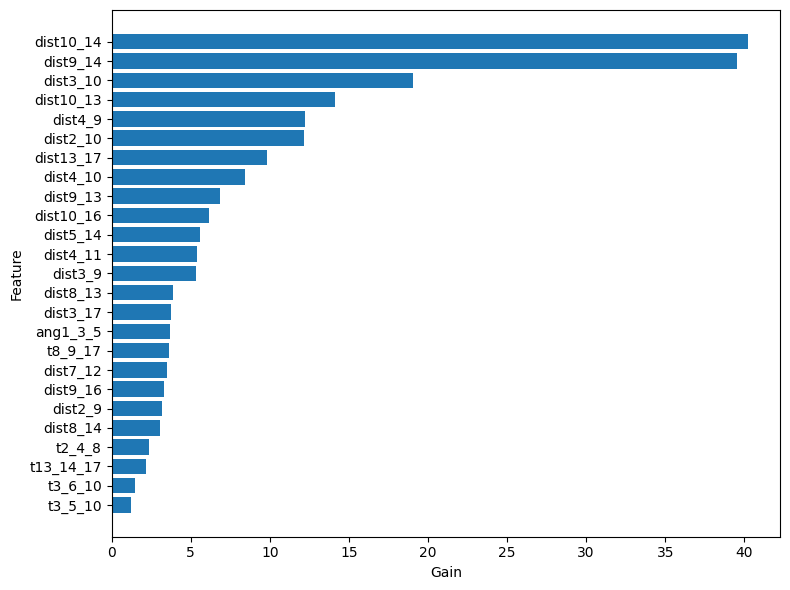

In [35]:
# === Feature-Mapping-Dictionary ===
feature_dict = {
    'f111': 'dist10_14', 'f104': 'dist9_14', 'f37': 'dist3_10', 'f110': 'dist10_13',
    'f49': 'dist4_9', 'f23': 'dist2_10', 'f129': 'dist13_17', 'f50': 'dist4_10',
    'f103': 'dist9_13', 'f113': 'dist10_16', 'f66': 'dist5_14', 'f51': 'dist4_11',
    'f36': 'dist3_9', 'f95': 'dist8_13', 'f44': 'dist3_17', 'f142': 'ang1_3_5',
    'f180': 't8_9_17', 'f85': 'dist7_12', 'f106': 'dist9_16', 'f22': 'dist2_9',
    'f96': 'dist8_14', 'f189': 't2_4_8', 'f202': 't13_14_17', 'f196': 't3_6_10',
    'f195': 't3_5_10'
}

# === Mapping anwenden ===
df_importance["Feature_mapped"] = df_importance["Feature"].replace(feature_dict)

# === Visualisierung ===
plt.figure(figsize=(8, 6))
plt.barh(df_importance["Feature_mapped"], df_importance["Gain"])
plt.xlabel("Gain")
plt.ylabel("Feature")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()


In [39]:
import pandas as pd
from pathlib import Path
from glob import glob

# Basisordner definieren
base = Path(r"C:\Users\Frede\OneDrive\Projects and Disschaptors\FIT_package\notebooks\results\fit_notebook_final_final_123\results\sex_modelling")

# Alle all_results.csv finden (eine Ebene tiefer, in species\tables)
paths = glob(str(base / "*" / "tables" / "all_results.csv"))

dfs, missing = [], []

for p in paths:
    pth = Path(p)
    sp = pth.parents[2].name  # \sex_modelling\<species>\tables\all_results.csv
    try:
        df = pd.read_csv(pth)
        if "species" not in df.columns:
            df["species"] = sp
        dfs.append(df)
    except Exception as e:
        missing.append(f"{pth} ({e})")

if not dfs:
    raise FileNotFoundError("Keine all_results.csv gefunden. Prüfe den Pfad in 'base'.")

# Zusammenführen
merged = pd.concat(dfs, ignore_index=True)

# species-Spalte nach vorne
cols = ["species"] + [c for c in merged.columns if c != "species"]
merged = merged[cols]

# Speichern
out_dir = base / "tables"
out_dir.mkdir(parents=True, exist_ok=True)
out_fp = out_dir / "all_species_all_results_merged.csv"
merged.to_csv(out_fp, index=False)

print(f"✅ Merged {len(dfs)} Dateien → {out_fp}")
if missing:
    print("⚠️ Fehler beim Laden:")
    for m in missing:
        print("  -", m)



✅ Merged 8 Dateien → C:\Users\Frede\OneDrive\Projects and Disschaptors\FIT_package\notebooks\results\fit_notebook_final_final_123\results\sex_modelling\tables\all_species_all_results_merged.csv
